# AVIRIS-NG CH₄ Hyperspectral Analysis — Physics, Mathematics & Machine Learning

AVIRIS-NG = Airborne Visible/Infrared Imaging Spectrometer – Next Generation.

$$
\boxed{\text{Physics} \rightarrow \text{Signal Processing} \rightarrow \text{Retrieval} \rightarrow \text{Machine Learning}}
$$

The pipeline uses real AVIRIS-NG radiance data and a CH₄ retrieval/reference product. It explicitly distinguishes retrieval-derived pseudo-labels from independent ground truth.

**Data source:** NASA Jet Propulsion Laboratory (JPL)

[AVIRIS-NG Benchmark Methane & Carbon Dioxide Data](https://popo.jpl.nasa.gov/avng/AVNG_Benchmark_Methane_Carbon_Dioxide_Data/?utm_source=chatgpt.com)


---

AVIRIS-NG = Airborne Visible/Infrared Imaging Spectrometer – Next Generation（次世代航空機搭載可視・赤外イメージング分光計）。

$$
\boxed{\text{物理学} \rightarrow \text{信号処理} \rightarrow \text{リトリーバル} \rightarrow \text{機械学習}}
$$

本パイプラインでは、実際のAVIRIS-NG放射輝度データとCH₄リトリーバル／参照プロダクトを使用する。

リトリーバルから得られた擬似ラベル（pseudo-label）と、独立したGround Truth（真値）を明確に区別する。

**データ提供元：** NASA Jet Propulsion Laboratory (JPL)

[AVIRIS-NG Benchmark Methane & Carbon Dioxide Data](https://popo.jpl.nasa.gov/avng/AVNG_Benchmark_Methane_Carbon_Dioxide_Data/?utm_source=chatgpt.com)

## 01. Project objective

The objective of this project is to reproduce a methane (CH₄) detection and estimation workflow using AVIRIS-NG hyperspectral radiance data, while preserving the physical interpretation of the spectral retrieval.

For pixel $(r,c)$, the spectrum is:

$$
\mathbf{x}_{r,c}=[R(\lambda_1),...,R(\lambda_B)].
$$

The project combines spectral analysis, signal processing, physical retrieval methods, and machine learning to detect and estimate CH₄.

The resulting workflow is then used to prepare a machine-learning model for rapid CH₄ identification and estimation in other hyperspectral images.

The project produces spectral diagnostics, a CH₄ reference map, detection and estimation models, full-scene prediction maps, and reproducible artifacts.

---

## 01. プロジェクトの目的

本プロジェクトの目的は、AVIRIS-NGのハイパースペクトル放射輝度データを用いて、メタン（CH₄）の検出・推定手法を再現し、スペクトルリトリーバルの物理的解釈を維持することである。

画素 $(r,c)$ におけるスペクトルは次のように表される。

$$
\mathbf{x}_{r,c}=[R(\lambda_1),...,R(\lambda_B)].
$$

スペクトル解析、信号処理、物理的リトリーバル手法、および機械学習を組み合わせて、CH₄の検出と推定を行う。

その結果得られた解析フローを基に、他のハイパースペクトル画像に対してCH₄を迅速に識別・推定できる機械学習モデルの準備を行う。

本プロジェクトでは、スペクトル診断、CH₄参照マップ、検出・推定モデル、シーン全体の予測マップ、および再現可能な解析成果物を作成する。

In [1]:
from pathlib import Path
import joblib
import numpy as np
import matplotlib.pyplot as plt
from spectral import open_image
from sklearn.decomposition import PCA
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, average_precision_score
)

## 02. Dataset and AVIRIS-NG instrument

The dataset contains AVIRIS-NG hyperspectral radiance data and a corresponding methane reference product.

Files used:

- `ang20160211t075004_rdn_v2m2_clip.hdr` — hyperspectral radiance cube.
- `ang20160211t075004_ch4.hdr` — methane matched-filter reference product.
- `ang20160211t075004_ch4_ua.txt` — auxiliary information associated with the methane product.

Each pixel therefore contains a 425-band spectrum. The methane-related spectral region is selected later from this full spectral range.

---

## 02. データセットとAVIRIS-NGセンサー

本データセットには、AVIRIS-NGのハイパースペクトル放射輝度データと、それに対応するメタン参照プロダクトが含まれる。

使用ファイル：

- `ang20160211t075004_rdn_v2m2_clip.hdr` — ハイパースペクトル放射輝度データ。
- `ang20160211t075004_ch4.hdr` — メタンのマッチドフィルター参照プロダクト。
- `ang20160211t075004_ch4_ua.txt` — メタンプロダクトに関連する補助情報。

各画素には425バンドのスペクトルが含まれる。メタン解析に使用する波長範囲は、この全スペクトル範囲から後の章で選択する。

In [2]:
# Paths
BASE_DIR = Path(".")

# Data files with radiance
RDN_HDR = BASE_DIR / "ang20160211t075004_rdn_v2m2_clip" / "ang20160211t075004_rdn_v2m2_clip.hdr"

# Data files with CH4 absorption
CH4_HDR = BASE_DIR / "ang20160211t075004_ch4" / "ang20160211t075004_ch4.hdr"

# Data file with CH4 unit absorption reference spectrum
UA_FILE = BASE_DIR / "ang20160211t075004_ch4" / "ang20160211t075004_ch4_ua.txt"

# Create output directories
OUTPUT_DIR = BASE_DIR / "outputs"
MODEL_DIR = BASE_DIR / "models"
FIG_DIR = OUTPUT_DIR / "figures"

for d in (OUTPUT_DIR, MODEL_DIR, FIG_DIR): 
    d.mkdir(parents=True, exist_ok=True)

for f in (RDN_HDR, CH4_HDR, UA_FILE):
    assert f.exists(), f"Missing {f}"
    
print("Required headers found.")

Required headers found.


## 03. Hyperspectral cube architecture and EDA

ENVI = ENvironment for VIsualizing images.

The AVIRIS-NG radiance data are represented as a three-dimensional hyperspectral data cube:

$$
R(r, c, \lambda),
$$

where $r$ denotes the spatial row, $c$ the spatial column, and $\lambda$ the spectral wavelength.

Each spatial pixel $(r,c)$ therefore contains a spectrum consisting of 425 radiance measurements:

$$
\mathbf{x}(r,c) =
[R(r,c,\lambda_1), ..., R(r,c,\lambda_B)]^T.
$$

The complete cube is retained in its original spatial and spectral structure for physical retrieval and spatial mapping.

Exploratory data analysis (EDA) is performed on the cube to characterize its dimensions, spectral range, data types, value distributions, missing or invalid values, and basic spatial and spectral properties.

When required for statistical or machine-learning analysis, selected spectral bands can be extracted and the spatial dimensions can be flattened into a two-dimensional matrix:

$$
X \in \mathbb{R}^{N\times B},
$$

where $N$ is the number of selected pixels and $B$ is the number of selected spectral bands.

The transformation to a two-dimensional matrix is performed only when required by a downstream analysis. The original cube coordinates $(r,c)$ are retained so that pixel-level results can subsequently be reconstructed as spatial maps.

---

## 03. ハイパースペクトルデータキューブの構造とEDA

ENVI = ENvironment for VIsualizing images（画像可視化環境）。

AVIRIS-NGの放射輝度データは、3次元のハイパースペクトルデータキューブとして表される。

$$
R(r, c, \lambda),
$$

ここで、$r$ は空間方向の行、$c$ は空間方向の列、$\lambda$ はスペクトル波長を表す。

したがって、空間位置 $(r,c)$ の各画素には、425個の波長における放射輝度値からなるスペクトルが存在する。

$$
\mathbf{x}(r,c) =
[R(r,c,\lambda_1), ..., R(r,c,\lambda_B)]^T.
$$

物理ベースのリトリーバルおよび空間マッピングでは、元の3次元構造を維持したままデータを扱う。

EDA（探索的データ解析）では、データキューブの次元、スペクトル範囲、データ型、値の分布、欠損値・無効値、および基本的な空間・スペクトル特性を確認する。

統計解析や機械学習などの後段の解析で必要となる場合には、選択したスペクトルバンドを抽出し、空間方向を2次元行列へ展開する。

$$
X \in \mathbb{R}^{N\times B},
$$

ここで、$N$ は選択された画素数、$B$ は使用するスペクトルバンド数を表す。

2次元行列への変換は、後段の解析で必要な場合にのみ行う。元の空間座標 $(r,c)$ は保持し、解析結果を再び画像座標へ戻して空間マップとして表示できるようにする。

In [3]:
# ------------------------------------------------------------
# 1. Open ~4 GB ENVI radiance cube using memory mapping
# ------------------------------------------------------------

rdn_img = open_image(RDN_HDR)
rdn_memmap = rdn_img.open_memmap()

wavelengths = np.asarray(rdn_img.bands.centers, dtype=np.float32)

print("=== AVIRIS-NG RADIANCE CUBE - 概要===")

print(f"Cube shape       : {rdn_memmap.shape}")
print(f"Data type        : {rdn_memmap.dtype}")
print(f"Number of rows   : {rdn_memmap.shape[0]}")
print(f"Number of columns: {rdn_memmap.shape[1]}")
print(f"Number of bands  : {rdn_memmap.shape[2]}")

print("\n=== WAVELENGTHS ===")

print(f"Wavelength count : {len(wavelengths)}")
print(f"Range            : {wavelengths.min():.3f} - {wavelengths.max():.3f} nm")
print(f"Median spacing   : {np.median(np.diff(wavelengths)):.3f} nm")
print(f"First 5          : {wavelengths[:5]}")
print(f"Last 5           : {wavelengths[-5:]}")

print("\n=== STRUCTURE CHECK ===")

print(f"Wavelengths match bands: {len(wavelengths) == rdn_memmap.shape[-1]}")
print(f"Wavelengths increasing : {np.all(np.diff(wavelengths) > 0)}")

=== AVIRIS-NG RADIANCE CUBE - 概要===
Cube shape       : (3987, 598, 425)
Data type        : float32
Number of rows   : 3987
Number of columns: 598
Number of bands  : 425

=== WAVELENGTHS ===
Wavelength count : 425
Range            : 376.440 - 2500.120 nm
Median spacing   : 5.010 nm
First 5          : [376.44 381.45 386.46 391.47 396.47]
Last 5           : [2480.08 2485.09 2490.1  2495.11 2500.12]

=== STRUCTURE CHECK ===
Wavelengths match bands: True
Wavelengths increasing : True


              
                  
          ┌───────────────┐
         /│              /│
        / │             / │
       └───────────────┘  │ ->column  約598列
       │  │               │ 
       │  └───────────────→ 
       │ /                /
       │/                /   --> 425 wavelength bands - 425スペクトルバンド
       └────────────────-
              ↓
             row 約3987行 

In [4]:
print("\n=== FILE METADATA ===")

metadata = rdn_img.metadata

items = list(metadata.items())

for i in range(0, len(items), 2):
    row = items[i:i + 2]

    parts = []
    for key, value in row:
        parts.append(f"{key}: {value}")

    print("    |    ".join(parts))


=== FILE METADATA ===
description: AVIRIS-NG Measured Radiances in uW nm-1 cm-2 sr-1    |    samples: 598
lines: 3987    |    bands: 425
header offset: 0    |    file type: ENVI
data type: 4    |    interleave: bil
byte order: 0    |    crosstrack scatter file: /home/jchapman/src/isat/ang/cal/data/20170125_via_ang20160925t182412_crf
wavelength units: Nanometers    |    flat field file: /home/jchapman/src/isat/ang/cal/data/20160912_via_ang20160111_BLUSS_avg_ff
wavelength file: /home/jchapman/src/isat/ang/cal/data/ang20150914t172022_wavelength_fit_full.txt    |    wavelength: ['376.44', '381.45', '386.46000000000004', '391.46999999999997', '396.46999999999997', '401.48', '406.49', '411.5', '416.51', '421.52', '426.53000000000003', '431.53999999999996', '436.53999999999996', '441.55', '446.56', '451.57000000000005', '456.58', '461.59', '466.6', '471.6', '476.60999999999996', '481.62', '486.63', '491.64000000000004', '496.65', '501.65999999999997', '506.66999999999996', '511.6699999999999

Shape: (425,) Finite: 425 (100.0%)


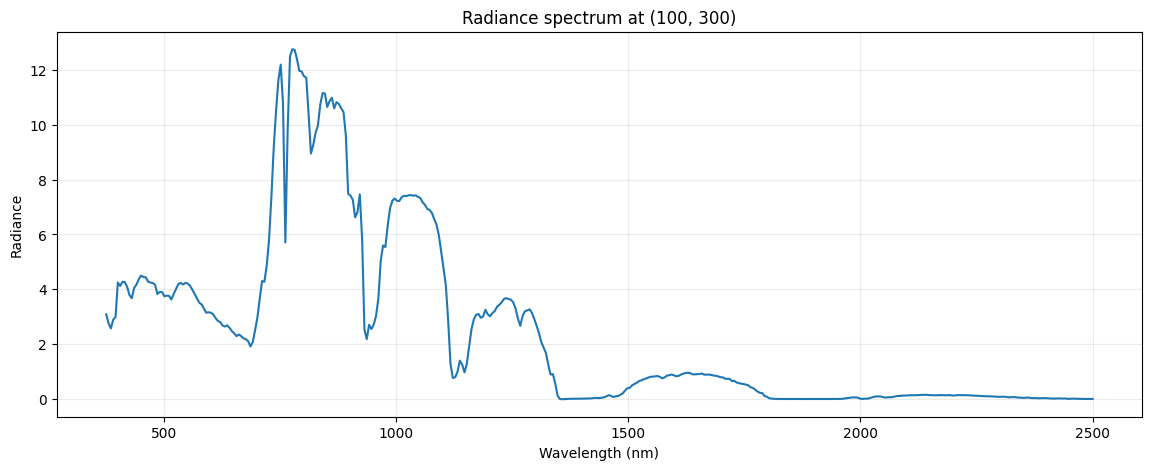

In [5]:
# ------------------------------------------------------------
# 2. Representative spectrum
# ------------------------------------------------------------
# Inspect one complete spectrum of a random pixel (100, 300): this IS the vector x_{r,c} from Section 02
# we cannot say that include the gas signature in the spectrum

random_row, random_col = 100, 300
spectrum = np.asarray(rdn_memmap[random_row, random_col, :], dtype=np.float32).squeeze()

print("Shape:", spectrum.shape, "Finite:", np.isfinite(spectrum).sum(), f"({np.isfinite(spectrum).sum() / len(spectrum) * 100:.1f}%)")

plt.figure(figsize=(14, 5))
plt.plot(wavelengths, spectrum)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Radiance")
plt.title(f"Radiance spectrum at ({random_row}, {random_col})")
plt.grid(alpha=.25)
plt.show()

| おおよその波長範囲         | 主な吸収成分           | 主な起源・用途                     |
| ----------------- | ---------------- | --------------------------- |
| 約400–700 nm       | 分子・電子遷移          | 植生、土壌、鉱物など                  |
| 約760 nm           | O₂               | 大気中の酸素                      |
| 約900–1000 nm      | H₂O              | 大気中の水蒸気、地表物質                |
| 約1200 nm          | H₂O              | 大気中の水蒸気、地表物質                |
| 約1400 nm          | **H₂O**          | 水蒸気による強い吸収帯                 |
| 約1900 nm          | **H₂O**          | 水蒸気による強い吸収帯                 |
| 約2000–2200 nm     | H₂O + 鉱物         | 水、粘土鉱物、炭酸塩鉱物など              |
| 約2120–2485 nm     | **CH₄ + その他の成分** | CH₄検出・解析に使用する広いスペクトル領域      |
| **約2298–2358 nm** | **CH₄**          | **CH₄の吸収特性を解析する主要なスペクトル領域** |



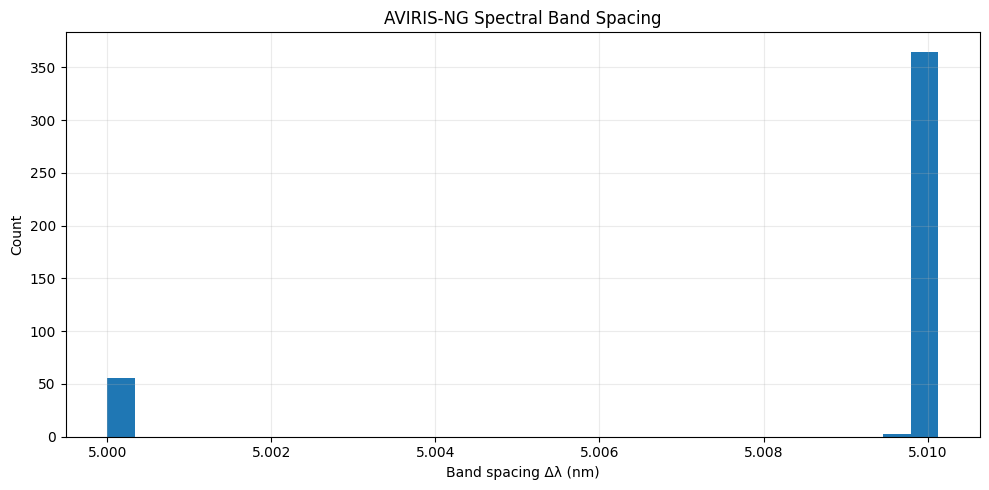

In [6]:
# ------------------------------------------------------------
# 3. Spectral band spacing - check the uniformity of the spectral sampling
# ------------------------------------------------------------

band_spacing = np.diff(wavelengths)

plt.figure(figsize=(10, 5))

plt.hist(
    band_spacing,
    bins=30
)

plt.xlabel("Band spacing Δλ (nm)")
plt.ylabel("Count")
plt.title("AVIRIS-NG Spectral Band Spacing")
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

帯域幅は均一ではない

## 04. Radiance and wavelength calibration validation — Demonstrative

### English

The AVIRIS-NG radiance product is already instrument-calibrated. This notebook does not perform the radiometric calibration itself; it loads the calibrated radiance values supplied in the ENVI product.

The wavelength calibration is also provided by the ENVI header. The header contains the center wavelength corresponding to each spectral band, so wavelengths must be read from the metadata rather than inferred from the band index.

The code below therefore validates the calibration metadata by checking:

- that the number of wavelengths matches the number of spectral bands;
- that wavelengths are monotonically increasing;
- that the wavelength range is physically plausible;
- that an example radiance spectrum contains only finite values.

Because the instrument has a finite spectral response function, each measured spectral band represents a finite spectral interval rather than an infinitely narrow molecular line.

---

## 04. 放射輝度と波長の校正の検証 — 実証例

### 日本語

AVIRIS-NGの放射輝度プロダクトには、すでにセンサーの校正が適用されている。本ノートブックでは放射輝度の校正そのものを実行せず、ENVIプロダクトに保存されている校正済みの放射輝度値を読み込む。

波長の校正情報もENVIヘッダーに含まれている。ヘッダーには各スペクトルバンドに対応する中心波長が記録されているため、波長はバンド番号から推定するのではなく、メタデータから読み込む。

したがって、以下のコードでは、校正に関するメタデータの整合性を次の項目について検証する。

- 波長の数がスペクトルバンド数と一致していること。
- 波長が単調増加していること。
- 波長範囲が物理的に妥当であること。
- 例として取得した放射輝度スペクトルに、NaNやInfなどの非有限値が含まれていないこと。

また、センサーには有限のスペクトル応答関数があるため、各測定バンドは無限に狭い分子吸収線ではなく、有限の波長範囲を表す。

In [7]:
print(
    "Header wavelengths are monotonically increasing:",
    np.all(np.diff(wavelengths) > 0)
)

print(
    "Header wavelength range (nm):",
    wavelengths.min(), "-", wavelengths.max()
)

print(
    "Wavelength count matches spectral bands:",
    len(wavelengths) == rdn_memmap.shape[2],
    f"({len(wavelengths)} wavelengths vs {rdn_memmap.shape[2]} spectral bands)"
)

print(
    "Wavelength range plausible:",
    300 < wavelengths.min() < 500
    and 2400 < wavelengths.max() < 2600,
    f"({wavelengths.min():.1f}-{wavelengths.max():.1f} nm)"
)

print(
    "Example spectrum fully finite:",
    np.isfinite(spectrum).all(),
    f"({np.isfinite(spectrum).sum()}/{len(spectrum)})"
)

Header wavelengths are monotonically increasing: True
Header wavelength range (nm): 376.44 - 2500.12
Wavelength count matches spectral bands: True (425 wavelengths vs 425 spectral bands)
Wavelength range plausible: True (376.4-2500.1 nm)
Example spectrum fully finite: True (425/425)


## 05. CH₄ molecular absorption physics — CH4 sensitive spectral interval

### English

Molecular transitions produce characteristic absorption structures in a spectrum. Conceptually, the measured spectrum can be represented as:

$$
R(\lambda)\approx C(\lambda)A_{CH4}(\lambda)+\epsilon(\lambda),
$$

where $C(\lambda)$ represents broad background and continuum effects, $A_{CH4}(\lambda)$ represents the methane-related spectral signature, and $\epsilon(\lambda)$ represents residual effects and noise.

Methane (CH₄) molecules absorb electromagnetic radiation at specific wavelengths.

This is a quantum-mechanical phenomenon associated with the vibrational and rotational states of the molecule.

When CH₄ is present, characteristic absorption structures therefore appear in the corresponding spectral region.

This project specifically analyzes the sensitive spectral interval

$$
2200\ \mathrm{nm} \leq \lambda \leq 2400\ \mathrm{nm}.
$$

This spectral interval contains absorption features that are sensitive to the presence of CH₄ and can therefore be used for CH₄ detection and retrieval.

However, the spectrum measured by the sensor is not a "pure CH₄ spectrum."

The observed signal is influenced by several factors, including:

- surface reflectance characteristics;
- atmospheric effects;
- absorption by other molecules;
- solar illumination;
- sensor characteristics and spectral response;
- measurement noise.

Therefore, extracting the CH₄ absorption signal requires separating CH₄-related spectral variations from the background and other contributions.

---

## 05. CH₄分子の吸収特性 — CH4 感度の高いスペクトル区間

### 日本語

分子遷移によって、スペクトルには特徴的な吸収構造が現れる。概念的には、観測スペクトルは次のように表すことができる。

$$
R(\lambda)\approx C(\lambda)A_{CH4}(\lambda)+\epsilon(\lambda),
$$

ここで、$C(\lambda)$ は広帯域の背景成分および連続スペクトルの影響、$A_{CH4}(\lambda)$ はメタンに関連するスペクトル特性、$\epsilon(\lambda)$ は残差成分およびノイズを表す。

メタン（CH₄）分子は、特定の波長の電磁波を吸収する。

これは、分子の振動状態および回転状態に関連する量子力学的な現象である。

そのため、CH₄が存在すると、対応するスペクトル領域に特徴的な吸収構造が現れる。

本プロジェクトでは、特にCH₄に対する感度の高いスペクトル区間として、次の波長範囲を解析する。

$$
2200\ \mathrm{nm} \leq \lambda \leq 2400\ \mathrm{nm}.
$$

このスペクトル区間には、CH₄の存在に感度を持つ吸収特性が含まれており、CH₄の検出およびリトリーバルに利用できる。

ただし、センサーが観測するスペクトルは「純粋なCH₄のスペクトル」ではない。

実際の観測信号には、以下のような複数の要因が影響する。

- 地表面の反射特性
- 大気の影響
- 他の分子による吸収
- 太陽光による照明条件
- センサーの特性およびスペクトル応答
- 観測ノイズ

したがって、CH₄の吸収信号を抽出するためには、背景成分やその他の影響からCH₄に関連するスペクトル変化を分離する必要がある。

Bands: 40 | Range: 2204.6-2399.9 nm


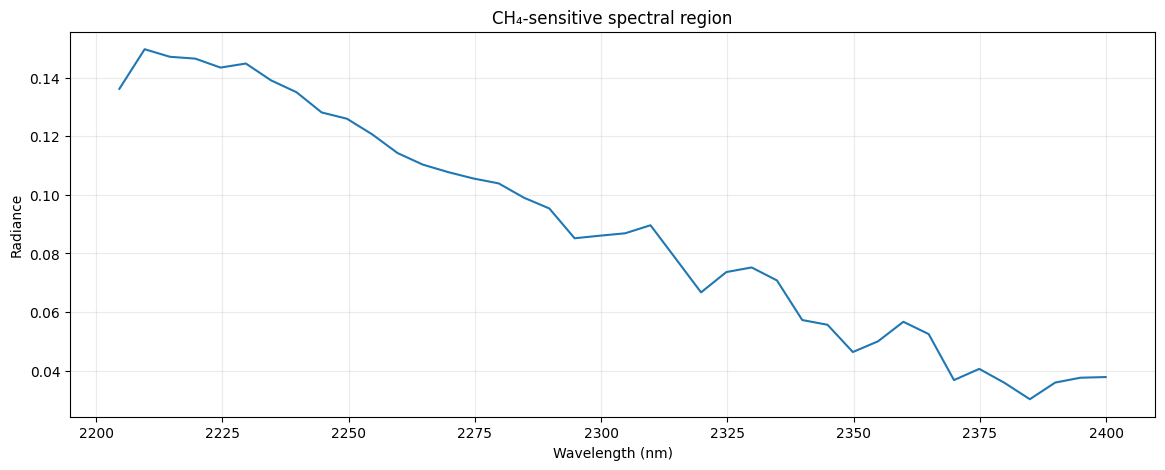

In [8]:
# CH4-sensitive spectral interval - include the full absorption window and some continuum on either side as shoulders
CH4_MIN, CH4_MAX = 2200.0, 2400.0

ch4_mask = (wavelengths >= CH4_MIN) & (wavelengths <= CH4_MAX)
ch4_indices = np.where(ch4_mask)[0]
ch4_wavelengths = wavelengths[ch4_mask]

print(f"Bands: {len(ch4_indices)} | Range: {ch4_wavelengths[0]:.1f}-{ch4_wavelengths[-1]:.1f} nm")

plt.figure(figsize=(14, 5))
plt.plot(ch4_wavelengths, spectrum[ch4_mask])
plt.xlabel("Wavelength (nm)")
plt.ylabel("Radiance")
plt.title("CH₄-sensitive spectral region")
plt.grid(alpha=.25)
plt.show()

## 06. Beer–Lambert model — Absorption equation — Demonstrative

### English

The fundamental attenuation model for the observed radiance is

$$
I(\lambda)=I_0(\lambda)e^{-\tau(\lambda)}
$$

where $I(\lambda)$ is the observed radiance and $I_0(\lambda)$ is the background or continuum radiance estimated in the absence of CH₄ absorption.

The optical depth is

$$
\tau(\lambda)=\sigma(\lambda)NL,
$$

where $\sigma(\lambda)$ is the absorption cross-section, $N$ is the molecular number density, and $L$ is the optical path length.

Therefore,

$$
-\ln\left(\frac{I}{I_0}\right)=\tau.
$$

Remote-sensing methane retrievals are commonly expressed as concentration-path length, such as ppm·m, rather than simply ppm.

---

## 06. Beer–Lambertモデル — 吸収式 — 実証例

### 日本語

光が吸収性物質を通過すると、放射輝度は減少する。この現象はBeer–Lambertの法則によって表される。

基本的な放射輝度の減衰モデルは次のように表される。

$$
I(\lambda)=I_0(\lambda)e^{-\tau(\lambda)}
$$

ここで、

- $I(\lambda)$：実際に観測された放射輝度
- $I_0(\lambda)$：CH₄吸収がない場合に推定される背景または連続スペクトルの放射輝度
- $\tau(\lambda)$：光学的厚さ（optical depth）

である。

光学的厚さは次のように表される。

$$
\tau(\lambda)=\sigma(\lambda)NL,
$$

ここで、$\sigma(\lambda)$ は吸収断面積、$N$ は分子数密度、$L$ は光路長を表す。

したがって、

$$
-\ln\left(\frac{I}{I_0}\right)=\tau
$$

となる。

リモートセンシングにおけるメタンのリトリーバルでは、濃度そのものを表すppmではなく、濃度と光路長の積であるppm·m（concentration-path length）で表現することが一般的である。

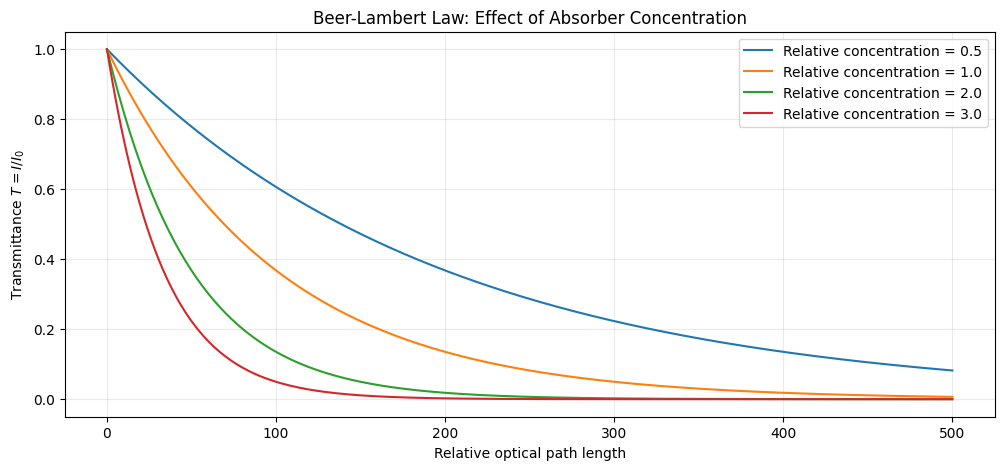

In [9]:
# --------------------------------------------------
# Synthetic Beer-Lambert demonstration
# --------------------------------------------------

# Relative optical path length
L = np.linspace(0, 500, 300)

# Relative absorber concentrations
concentrations = [0.5, 1.0, 2.0, 3.0]

# Arbitrary absorption coefficient
alpha = 0.01

plt.figure(figsize=(12, 5))

for C in concentrations:
    tau = alpha * C * L
    transmittance = np.exp(-tau)

    plt.plot(
        L,
        transmittance,
        label=f"Relative concentration = {C}"
    )

plt.xlabel("Relative optical path length")
plt.ylabel(r"Transmittance $T = I/I_0$")
plt.title("Beer-Lambert Law: Effect of Absorber Concentration")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 07. CH₄ absorption data analysis

### English

The next step is to load the CH₄ absorption data used in the retrieval.

The absorption information provides the spectral response of methane as a function of wavelength and is used to characterize the CH₄ absorption features within the selected spectral interval.

These data will subsequently be used as the reference spectral information for the physical CH₄ retrieval and matched-filter analysis.

---

## 07. CH₄吸収データ 分析

### 日本語

次の段階では、リトリーバルに使用するCH₄の吸収データを読み込む。

吸収データには、波長に対するメタンのスペクトル応答に関する情報が含まれており、選択したスペクトル区間におけるCH₄の吸収特性を解析するために使用する。

これらのデータは、その後の物理的なCH₄リトリーバルおよびマッチドフィルター解析における参照スペクトル情報として使用する。

In [10]:
# ============================================================
# Reading the CH4 image and constructing the reference map
# define absorption window for CH4
# separate filters and albedo factor
# ============================================================


# Open the CH4 image and construct the reference map 'ref'
ch4_img = open_image(str(CH4_HDR))

# load the CH4 image data into a numpy array, using memory mapping if available
open_memmap = getattr(ch4_img, "open_memmap", None)

if callable(open_memmap):
    ch4_array = np.asarray(open_memmap())
else:
    load = getattr(ch4_img, "load", None)
    if not callable(load):
        raise TypeError("The CH4 image object has neither open_memmap() nor load().")
    ch4_array = np.asarray(load())

# read band names from metadata (informativ, pastrat pentru print/log)
names = ch4_img.metadata.get("band names", [])
print("=== CH₄ Reference Image ===")
print(f"Shape : {ch4_array.shape}")
print(f"Dtype : {ch4_array.dtype}")
print(f"Bands : {len(names)}")
print("Band Names:")
for i, name in enumerate(names, start=1):
    print(f"{i} {name}")

=== CH₄ Reference Image ===
Shape : (3987, 598, 5)
Dtype : float32
Bands : 5
Band Names:
1 Red Radiance (uW nm-1 cm-2 sr-1)
2 Green Radiance
3 Blue Radiance
4 Matched Filter Results (ppm m)
5 Albedo Factor (dimensionless)


``` text
        z: bands (5)
        Red,Green,Blue,MF,Albedo
              ^
              |
        +-----------+
       /|          /|
      / |         / |
     +-----------+  |
     |  |        |  |--> y: samples (598)
     |  +--------|--+
     | /         | /
     |/          |/
     +-----------+
           |
           v
     x: lines (3987)

shape = (3987, 598, 5) = (x, y, z) = (lines, samples, bands)

x = lines (3987) — the sensor's flight direction (front-to-back, "along-track"). Each step along this axis is a new scan line, captured at a different moment in time as the aircraft moves forward.
y = samples (598) — the width of the scanned swath, perpendicular to the flight direction (left-right on the ground, "cross-track"). Fixed at 598, because the sensor has a fixed-width row of detectors — this number is a hardware property, not something that changes between flights.
z = bands (5) — not spatial at all; it's the "depth" of the cube. At every ground point (x, y), you have 5 different values stacked on top of each other (Red, Green, Blue, Matched Filter, Albedo) — think of it as 5 different channels of information for the same location, not 5 different places.
```


In [11]:
# CH₄ reference and albedo maps
# pixels containing irrelevant data are marked as NaN in the reference and albedo maps,
# which will be used for further analysis.

if isinstance(names, str):
    names = [names]

# ------------------------------------------------------------
# 1. CH₄ matched-filter reference map
# ------------------------------------------------------------

CH4_FILTER = 3
print(f"CH₄ matched-filter band: {CH4_FILTER} ({names[CH4_FILTER]})")

ref = ch4_array[:, :, CH4_FILTER].astype(np.float32, copy=True)

# NoData value from ENVI metadata
nodata_meta = ch4_img.metadata.get("data ignore value")
nodata = float(nodata_meta) if nodata_meta is not None else -9999.0

print(f"NoData value: {nodata}")

ref[ref == nodata] = np.nan

# Reference map checks
print("\n=== CH₄ reference map ===")
print(f"Shape : {ref.shape}")
print(f"Finite: {np.isfinite(ref).sum():,}")
print(f"NaN   : {np.isnan(ref).sum():,}")
print(f"Inf   : {np.isinf(ref).sum():,}")


# ------------------------------------------------------------
# 2. CH₄ albedo factor map
# ------------------------------------------------------------

CH4_ALBEDO = 4
print(f"\nCH₄ albedo band: {CH4_ALBEDO} ({names[CH4_ALBEDO]})")

alb = ch4_array[:, :, CH4_ALBEDO].astype(np.float32, copy=True)

alb[alb == nodata] = np.nan

# Albedo map checks
print("\n=== CH₄ albedo map ===")
print(f"Shape : {alb.shape}")
print(f"Finite: {np.isfinite(alb).sum():,}")
print(f"NaN   : {np.isnan(alb).sum():,}")
print(f"Inf   : {np.isinf(alb).sum():,}")


# ------------------------------------------------------------
# 3. Valid pixels
# ------------------------------------------------------------

valid_mask = np.isfinite(ref) & np.isfinite(alb)

print("\n=== Valid pixels ===")
print(f"Valid pixels: {valid_mask.sum():,}")


# ------------------------------------------------------------
# 4. Full value analysis
# ------------------------------------------------------------

ref_values = ref[np.isfinite(ref)]
alb_values = alb[np.isfinite(alb)]


print(np.sort(alb_values)[-10:])

CH₄ matched-filter band: 3 (Matched Filter Results (ppm m))
NoData value: -9999.0

=== CH₄ reference map ===
Shape : (3987, 598)
Finite: 2,356,120
NaN   : 28,106
Inf   : 0

CH₄ albedo band: 4 (Albedo Factor (dimensionless))

=== CH₄ albedo map ===
Shape : (3987, 598)
Finite: 2,356,120
NaN   : 28,106
Inf   : 0

=== Valid pixels ===
Valid pixels: 2,356,120
[5.036233  5.116408  5.3145976 5.5323415 6.4330125 6.500053  7.7289762
 8.931457  9.081131  9.58024  ]


In [12]:
# ---- Matched Filter ----

ref_negative = np.sum(ref_values < 0)
ref_zero     = np.sum(ref_values == 0)
ref_positive = np.sum(ref_values > 0)

print("\n=== CH₄ Matched Filter value analysis ===")
print(f"Min      : {ref_values.min():.6f}")
print(f"Max      : {ref_values.max():.6f}")
print(f"Mean     : {ref_values.mean():.6f}")
print(f"Median   : {np.median(ref_values):.6f}")
print(f"Negative : {ref_negative:,} ({100 * ref_negative / len(ref_values):.4f}%)")
print(f"Zero     : {ref_zero:,} ({100 * ref_zero / len(ref_values):.4f}%)")
print(f"Positive : {ref_positive:,} ({100 * ref_positive / len(ref_values):.4f}%)")

print("\nSmallest 10 MF values:")
print(np.sort(ref_values)[:10])

print("\nLargest 10 MF values:")
print(np.sort(ref_values)[-10:])


# ---- Albedo ----

alb_negative = np.sum(alb_values < 0)
alb_zero     = np.sum(alb_values == 0)
alb_positive = np.sum(alb_values > 0)

print("\n=== CH₄ Albedo value analysis ===")
print(f"Min      : {alb_values.min():.6f}")
print(f"Max      : {alb_values.max():.6f}")
print(f"Mean     : {alb_values.mean():.6f}")
print(f"Median   : {np.median(alb_values):.6f}")
print(f"Negative : {alb_negative:,} ({100 * alb_negative / len(alb_values):.4f}%)")
print(f"Zero     : {alb_zero:,} ({100 * alb_zero / len(alb_values):.4f}%)")
print(f"Positive : {alb_positive:,} ({100 * alb_positive / len(alb_values):.4f}%)")

print("\nSmallest 10 albedo values:")
print(np.sort(alb_values)[:10])

print("\nLargest 10 albedo values:")


=== CH₄ Matched Filter value analysis ===
Min      : 0.000000
Max      : 14208.378906
Mean     : 33.189114
Median   : 0.000000
Negative : 0 (0.0000%)
Zero     : 2,213,930 (93.9651%)
Positive : 142,190 (6.0349%)

Smallest 10 MF values:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Largest 10 MF values:
[ 9635.122  9815.493  9834.736  9943.393 10512.946 10766.264 11038.326
 11332.748 11682.04  14208.379]

=== CH₄ Albedo value analysis ===
Min      : 0.069717
Max      : 9.580240
Mean     : 1.000020
Median   : 1.019830
Negative : 0 (0.0000%)
Zero     : 0 (0.0000%)
Positive : 2,356,120 (100.0000%)

Smallest 10 albedo values:
[0.06971739 0.06980368 0.0706218  0.07110666 0.07170582 0.07178509
 0.07183502 0.07247419 0.07249304 0.07253835]

Largest 10 albedo values:


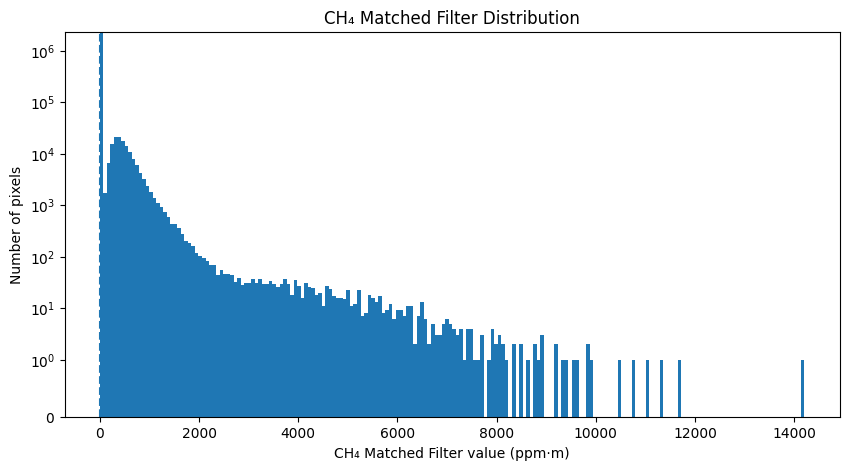

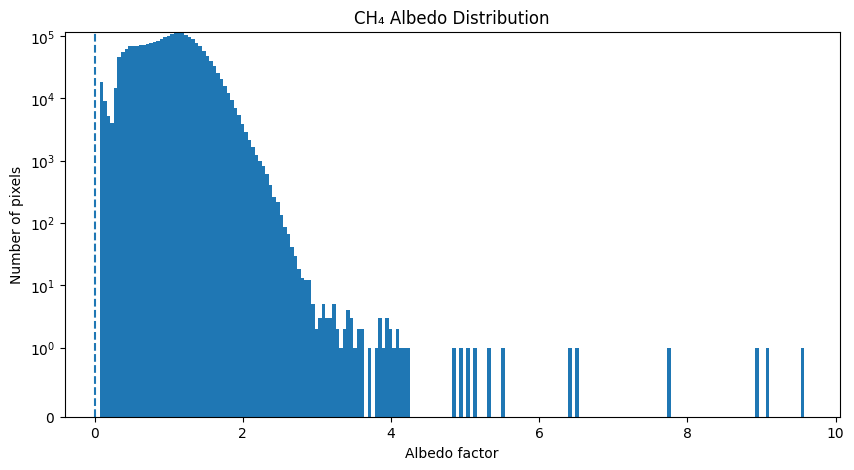

In [13]:
# ------------------------------------------------------------
# 5. Histograms
# ------------------------------------------------------------

ref_finite_hist = ref[np.isfinite(ref)]
alb_finite_hist = alb[np.isfinite(alb)]

ref_counts, ref_edges = np.histogram(ref_finite_hist, bins=200)
alb_counts, alb_edges = np.histogram(alb_finite_hist, bins=200)

ref_centers = (ref_edges[:-1] + ref_edges[1:]) / 2
alb_centers = (alb_edges[:-1] + alb_edges[1:]) / 2

plt.figure(figsize=(10, 5))
plt.bar(ref_centers, ref_counts, width=np.diff(ref_edges), align="center")
plt.axvline(0, linestyle="--")
plt.yscale("symlog", linthresh=1)
plt.xlabel("CH₄ Matched Filter value (ppm·m)")
plt.ylabel("Number of pixels")
plt.title("CH₄ Matched Filter Distribution")
plt.show()


plt.figure(figsize=(10, 5))
plt.bar(alb_centers, alb_counts, width=np.diff(alb_edges), align="center")
plt.axvline(0, linestyle="--")
plt.yscale("symlog", linthresh=1)
plt.xlabel("Albedo factor")
plt.ylabel("Number of pixels")
plt.title("CH₄ Albedo Distribution")
plt.show()

red: band 55, wavelength = 651.9 nm
green: band 35, wavelength = 551.7 nm
blue: band 15, wavelength = 451.6 nm


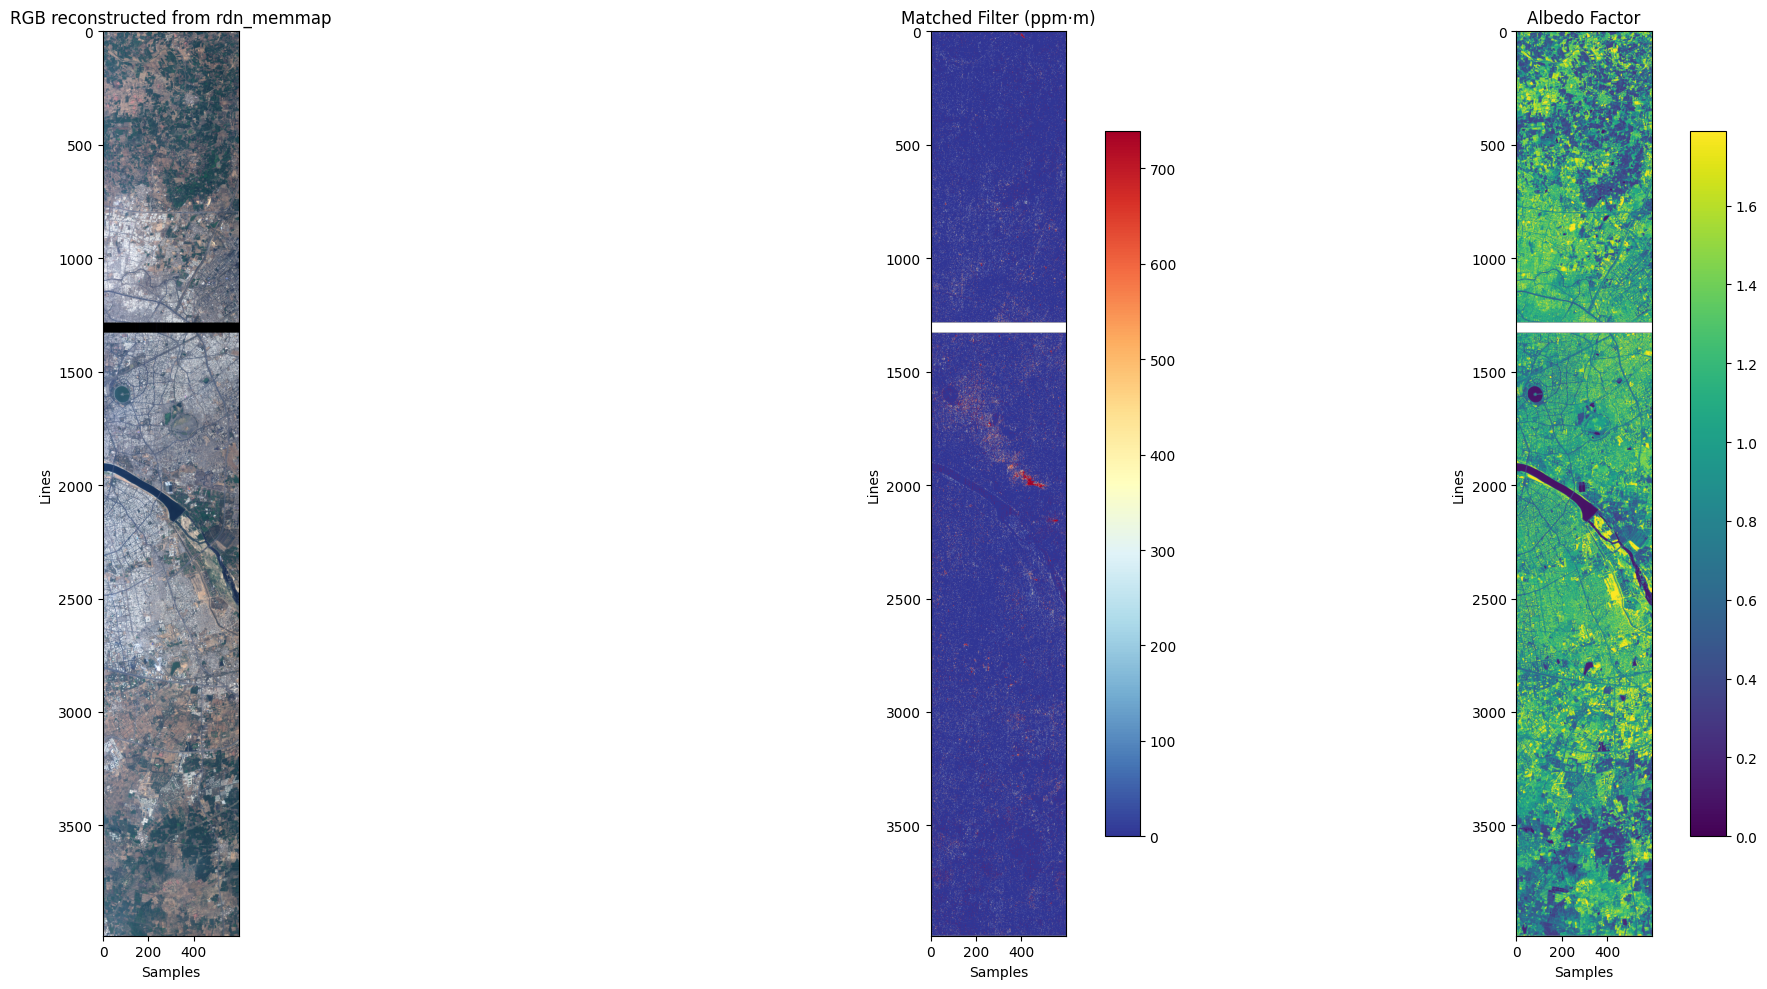

In [14]:
# ------------------------------------------------------------------------------
# Data visualization — Create a normalized version of a band for visualization
# ------------------------------------------------------------------------------
# Matplotlib.imshow cu date RGB float așteaptă valorile în intervalul [0, 1] (sau [0, 255] dacă sunt integers) — 
# dar red_full, green_full, blue_full sunt radianță brută, cu valori complet arbitrare (ar putea fi orice, de la 0 la sute sau mii, 
# în funcție de unități).

def normalize(band, pmin=1, pmax=99):
    lo, hi = np.nanpercentile(band, [pmin, pmax])
    return np.clip((band - lo) / (hi - lo), 0, 1)

# RGB bands
target_wavelengths = {'red': 650, 'green': 550, 'blue': 450}
rgb_band_indices = {
    c: np.argmin(np.abs(wavelengths - wl))
    for c, wl in target_wavelengths.items()
}

for c, i in rgb_band_indices.items():
    print(f"{c}: band {i}, wavelength = {wavelengths[i]:.1f} nm")

rgb = []
for c in ['red', 'green', 'blue']:
    band = np.array(rdn_memmap[:, :, rgb_band_indices[c]], dtype=np.float32, copy=True)
    band[band == nodata] = np.nan
    rgb.append(normalize(band))

rgb_reconstructed = np.dstack(rgb)

# Display RGB, matched filter and albedo
fig, axes = plt.subplots(1, 3, figsize=(20, 10))

axes[0].imshow(rgb_reconstructed)
axes[0].set_title("RGB reconstructed from rdn_memmap")

im1 = axes[1].imshow(ref, cmap='RdYlBu_r', vmin=0, vmax=np.nanpercentile(ref, 99))
axes[1].set_title("Matched Filter (ppm·m)") # values from 700 to 14000 ppm * m are cuttet (0 - 99 %)
plt.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(alb, cmap='viridis', vmin=0, vmax=np.nanpercentile(alb, 98))
axes[2].set_title("Albedo Factor")
plt.colorbar(im2, ax=axes[2], fraction=0.046)

for ax in axes:
    ax.set_xlabel("Samples")
    ax.set_ylabel("Lines")

plt.tight_layout()
plt.show()

### English

**Threshold**

The `threshold` is a statistical value used to separate background pixels from CH₄ candidate pixels based on the matched-filter reference values.

The matched filter produces both negative and positive values. These values can be interpreted as:

1. **Negative values** → response opposite to the CH₄ reference spectrum or background fluctuations.
2. **Values around zero** → no clear CH₄ signal.
3. **Positive values** → response in the direction of the CH₄ reference spectrum.

The original `ref` map retains all valid values, including negative values. However, only positive values are used to determine the detection threshold because the objective is to identify strong positive responses to the CH₄ spectrum.

In this project:

`threshold = np.percentile(ref_pos, 98)`

where `ref_pos` contains only positive finite reference values. The threshold therefore corresponds to the **98th percentile of the positive CH₄ reference values**. Approximately 2% of the positive values are above this threshold.

The threshold is then used to define candidate labels:

- `ref < threshold` → background candidate
- `ref ≥ threshold` → CH₄ candidate

The threshold is expressed in **ppm·m**, because the matched-filter reference represents CH₄ concentration-path length.

The threshold is a **statistical classification criterion**, not a directly measured physical CH₄ concentration. It is used to generate candidate labels for the subsequent ML classification.

---

### 日本語

**しきい値（Threshold）**

`threshold` は、マッチドフィルターのリファレンス値に基づいて、背景画素とCH₄候補画素を分離するために使用する統計的なしきい値です。

マッチドフィルターでは、正の値と負の値の両方が得られます。これらの値は、概念的に次のように解釈できます。

1. **負の値** → CH₄リファレンススペクトルとは反対方向の応答、または背景の変動。
2. **0付近の値** → 明確なCH₄信号がない状態。
3. **正の値** → CH₄リファレンススペクトルの方向への応答。

元の `ref` マップには、負の値を含むすべての有効な値を保持します。ただし、検出しきい値はCH₄スペクトルに対する強い正の応答を識別することを目的としているため、しきい値の計算には正の値のみを使用します。

このプロジェクトでは、

`threshold = np.percentile(ref_pos, 98)`

とし、`ref_pos` には有限な正のリファレンス値のみを使用します。したがって、しきい値は**正のCH₄リファレンス値の98パーセンタイル**に相当し、正の値のおよそ2%がこのしきい値以上になります。

このしきい値を使用して候補ラベルを定義します。

- `ref < threshold` → 背景候補
- `ref ≥ threshold` → CH₄候補

しきい値の単位は **ppm·m** です。これはマッチドフィルターのリファレンス値がCH₄の濃度と光路長の積を表すためです。

このしきい値は**統計的な分類基準**であり、直接測定されたCH₄濃度そのものではありません。その後のML分類用の候補ラベルを作成するために使用します。

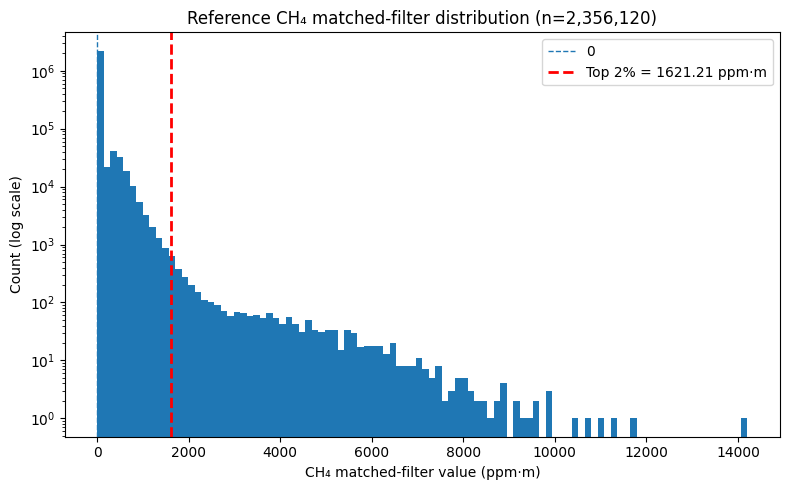

Threshold: 1621.2074 ppm·m
Background candidates: 2,353,276
Plume candidates: 2,844


In [15]:
# Distribution of positive reference CH₄ values
ref_finite = ref[np.isfinite(ref)]
ref_pos = ref_finite[ref_finite > 0]

threshold = np.percentile(ref_pos, 98)

plt.figure(figsize=(8, 5))
plt.hist(ref_finite, bins=100)
plt.axvline(0, linestyle='--', linewidth=1, label='0')
plt.axvline(
    float(threshold), color="red", linestyle="--", linewidth=2,
    label=f"Top 2% = {threshold:.2f} ppm·m"
)

plt.yscale('log')
plt.title(f"Reference CH₄ matched-filter distribution (n={ref_finite.size:,})")
plt.xlabel("CH₄ matched-filter value (ppm·m)")
plt.ylabel("Count (log scale)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Threshold: {threshold:.4f} ppm·m")
print(f"Background candidates: {(ref_finite < threshold).sum():,}")
print(f"Plume candidates: {(ref_finite >= threshold).sum():,}")

## 08. Continuum Removal

### English

A smooth continuum is estimated using a second-order polynomial fitted only to the shoulder bands outside the main CH₄ absorption region (2298–2358 nm).

$$
C(\lambda)=a_0+a_1\lambda+a_2\lambda^2
$$

The final spectrum is obtained by dividing the original spectrum by the estimated continuum.

$$
X_p(\lambda)=\frac{X(\lambda)}{C(\lambda)}
$$

This removes the broad spectral shape while preserving the relative CH₄ absorption feature.

$$
\boxed{
\text{Radiance}
\rightarrow
\text{Continuum Removal}
\rightarrow
X_p
}
$$

---

### 日本語

## 08. Continuum Removal — 連続スペクトルの除去

主なCH₄吸収領域（2298–2358 nm）の外側にあるショルダーバンドのみを使用し、2次多項式によって滑らかなcontinuumを推定します。

$$
C(\lambda)=a_0+a_1\lambda+a_2\lambda^2
$$

推定したcontinuumで元のスペクトルを除算することで、最終的なスペクトルを求めます。

$$
X_p(\lambda)=\frac{X(\lambda)}{C(\lambda)}
$$

これにより、広域的なスペクトル形状を除去し、CH₄吸収による相対的なスペクトル特徴を保持します。

$$
\boxed{
\text{Radiance}
\rightarrow
\text{Continuum Removal}
\rightarrow
X_p
}
$$

``` text
shoulders:    |----------------|       |----------------|
            2200             2298     2358            2400
                                  CH4
```

In [16]:
# Define absorption window for CH₄ - without shoulders
CH4_ABS_MIN, CH4_ABS_MAX = 2298.0, 2358.0



# ============================================================
# A. PIXELS SAMPLING
# ============================================================
rows_all, cols_all = np.where(valid_mask)
print(f"Initial sample: {len(rows_all):,} pixels")

# ============================================================
# B. INVALID PIXEL REMOVAL (RADIANCE)
# ============================================================

Xp = np.asarray(
    rdn_memmap[rows_all, cols_all][:, ch4_indices],
    dtype=np.float32
)

finite_mask = np.isfinite(Xp).all(axis=1) & (Xp > 0).all(axis=1)

Xp = Xp[finite_mask]
rows_valid, cols_valid = rows_all[finite_mask], cols_all[finite_mask]
ref_valid = ref[rows_valid, cols_valid]

print(f"Valid pixels: {Xp.shape[0]:,} ({100*Xp.shape[0]/len(rows_all):.1f}%)")
print(f"Xp sampled pixels non-empty: {Xp.shape[0] > 100} ({Xp.shape[0]} pixels)")
print(f"Xp fully finite and positive: {np.isfinite(Xp).all() and (Xp > 0).all()}")

# ============================================================
# E. CONTINUUM REMOVAL
# ============================================================
shoulder_mask = ~(
    (ch4_wavelengths >= CH4_ABS_MIN) &
    (ch4_wavelengths <= CH4_ABS_MAX)
)

print(
    f"Shoulder mask covers most bands: "
    f"{shoulder_mask.sum() > 0.5 * len(ch4_wavelengths)} "
    f"({shoulder_mask.sum()}/{len(ch4_wavelengths)} bands)"
)

V_shoulder = np.column_stack([
    ch4_wavelengths[shoulder_mask]**2,
    ch4_wavelengths[shoulder_mask],
    np.ones(shoulder_mask.sum())
]).astype(np.float32)

V_all = np.column_stack([
    ch4_wavelengths**2,
    ch4_wavelengths,
    np.ones(len(ch4_wavelengths))
]).astype(np.float32)

continuum_operator = np.linalg.pinv(V_shoulder).astype(np.float32)
coeffs = Xp[:, shoulder_mask] @ continuum_operator.T
continuum = coeffs @ V_all.T
Xp_ratio = Xp / np.clip(continuum, 1e-6, None)

print(f"Xp_ratio finite everywhere: {np.isfinite(Xp_ratio).all()}")
print(
    f"Xp_ratio centered near 1.0 on shoulders: "
    f"{abs(Xp_ratio[:, shoulder_mask].mean() - 1.0) < 0.05} "
    f"(mean={Xp_ratio[:, shoulder_mask].mean():.4f})"
)
print(
    f"Xp_ratio dips inside CH₄ window: "
    f"{Xp_ratio[:, ~shoulder_mask].mean() <= Xp_ratio[:, shoulder_mask].mean()}"
)

Initial sample: 2,356,120 pixels
Valid pixels: 2,356,120 (100.0%)
Xp sampled pixels non-empty: True (2356120 pixels)
Xp fully finite and positive: True
Shoulder mask covers most bands: True (28/40 bands)
Xp_ratio finite everywhere: True
Xp_ratio centered near 1.0 on shoulders: True (mean=1.0010)
Xp_ratio dips inside CH₄ window: True


CH₄ candidates: 2,844
Background: 2,353,276


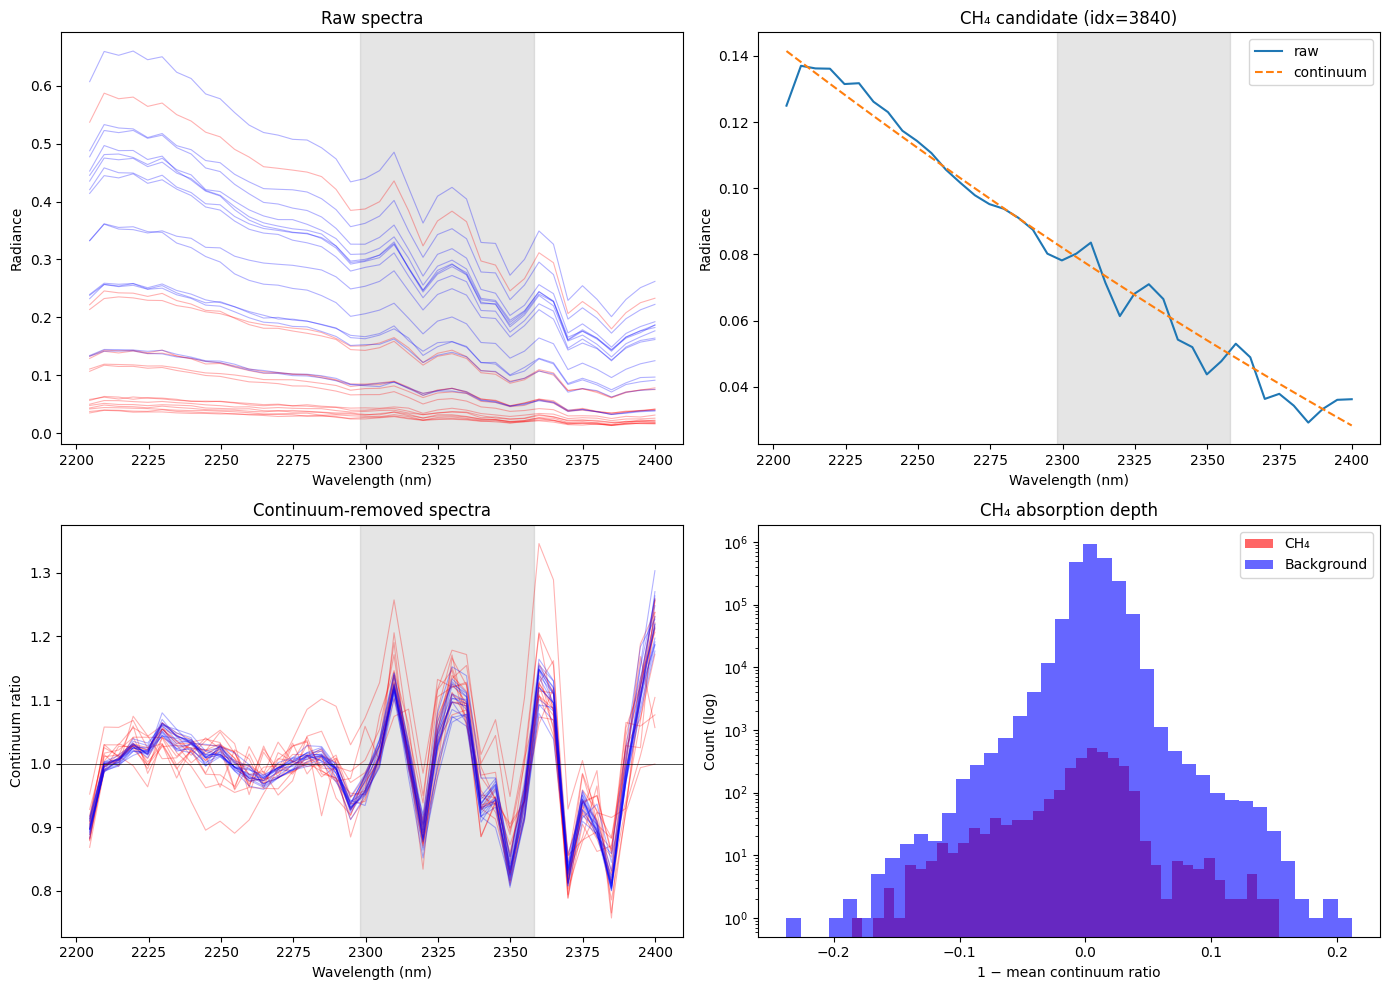

In [17]:
# CH₄ candidates vs background

is_ch4_candidate = ref_valid >= threshold
idx_ch4 = np.where(is_ch4_candidate)[0]
idx_bg = np.where(~is_ch4_candidate)[0]

print(f"CH₄ candidates: {len(idx_ch4):,}")
print(f"Background: {len(idx_bg):,}")

rng = np.random.default_rng(0)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Raw spectra
ax = axes[0, 0]
for i in rng.choice(idx_ch4, min(15, len(idx_ch4)), False):
    ax.plot(ch4_wavelengths, Xp[i], 'r', alpha=.3, lw=.8)
for i in rng.choice(idx_bg, min(15, len(idx_bg)), False):
    ax.plot(ch4_wavelengths, Xp[i], 'b', alpha=.3, lw=.8)
ax.axvspan(CH4_ABS_MIN, CH4_ABS_MAX, color='gray', alpha=.2)
ax.set_title("Raw spectra")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Radiance")

# 2. Raw vs continuum
ax = axes[0, 1]
i0 = idx_ch4[0]
ax.plot(ch4_wavelengths, Xp[i0], label="raw")
ax.plot(ch4_wavelengths, continuum[i0], '--', label="continuum")
ax.axvspan(CH4_ABS_MIN, CH4_ABS_MAX, color='gray', alpha=.2)
ax.set_title(f"CH₄ candidate (idx={i0})")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Radiance")
ax.legend()

# 3. Continuum removed
ax = axes[1, 0]
for i in rng.choice(idx_ch4, min(15, len(idx_ch4)), False):
    ax.plot(ch4_wavelengths, Xp_ratio[i], 'r', alpha=.3, lw=.8)
for i in rng.choice(idx_bg, min(15, len(idx_bg)), False):
    ax.plot(ch4_wavelengths, Xp_ratio[i], 'b', alpha=.3, lw=.8)
ax.axhline(1, color='k', lw=.5)
ax.axvspan(CH4_ABS_MIN, CH4_ABS_MAX, color='gray', alpha=.2)
ax.set_title("Continuum-removed spectra")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Continuum ratio")

# 4. CH₄ absorption depth
ax = axes[1, 1]

depth = 1 - Xp_ratio[:, ~shoulder_mask].mean(axis=1)

ax.hist(depth[is_ch4_candidate], bins=40, alpha=.6, color='red', label='CH₄')
ax.hist(depth[~is_ch4_candidate], bins=40, alpha=.6, color='blue', label='Background')

ax.set_yscale('log')
ax.set_title("CH₄ absorption depth")
ax.set_xlabel("1 − mean continuum ratio")
ax.set_ylabel("Count (log)")
ax.legend()

plt.tight_layout()
plt.show()

## CH₄ Absorption Depth

The absorption depth is defined as:

$$
\text{Depth}
=
1-\operatorname{mean}\left(\frac{X_p}{C}\right)
$$

where:

* **Depth > 0** → the spectrum is below the continuum → **absorption**
* **Depth ≈ 0** → the spectrum is close to the continuum → **weak or no absorption**
* **Depth < 0** → the spectrum is above the continuum → **no absorption**

Therefore, in this metric, **positive values indicate spectral absorption** within the CH₄ absorption window.

However, a positive absorption depth does **not automatically mean CH₄ is present**. Other gases, spectral noise, and continuum-estimation errors can also produce positive values. CH₄ identification is based on the spectral absorption pattern together with the CH₄ reference spectrum / Matched Filter.


## 09. Fourier Spectral Analysis — Demonstration

### English

For a sampled spectrum $x_n$,

$$
X_k=\sum_{n=0}^{N-1}x_ne^{-i2\pi kn/N}
$$

We inspect $|X_k|$ to diagnose broad versus rapid spectral variations, noise, and smoothing effects.

**FFT is not used for CH₄ retrieval.** CH₄ absorption is a single localized dip (2298–2358 nm), not a periodic signal. FFT is designed for detecting periodicities, not isolated spectral features. Matched filtering and continuum removal compare the spectral **shape** directly in the wavelength domain, which is what characterizes molecular absorption. This section is for demonstration only; no result feeds into later sections.

**Note:** Band spacing is not perfectly uniform, so the frequency axis below uses the **median** band spacing as a diagnostic approximation, not a calibrated frequency axis.

---

### 日本語

## 09. Fourier Spectral Analysis — フーリエスペクトル解析（実例）

サンプリングされたスペクトル $x_n$ に対して、

$$
X_k=\sum_{n=0}^{N-1}x_ne^{-i2\pi kn/N}
$$

$|X_k|$ を調べることで、緩やかな変化と急激な変化、ノイズ、平滑化の影響を診断する。

**FFTはCH₄検出には使用しない。** CH₄吸収は局在した単一の落ち込み（2298–2358 nm）であり、周期信号ではない。FFTは周期性の検出に適した手法であり、孤立したスペクトル形状の検出を目的とするものではない。Matched Filterとcontinuum removal はスペクトルの**形状**を波長領域で直接比較するため、分子吸収の特徴づけに適している。本セクションはデモンストレーション目的のみで、結果は以降のセクションでは使用しない。

**注：** バンド間隔は完全に均一ではないため、以下の周波数軸は**中央値**のバンド間隔による診断的近似であり、校正済みの周波数軸ではない。

Δλ median=5.010010 nm, range=5.000000-5.010010 nm


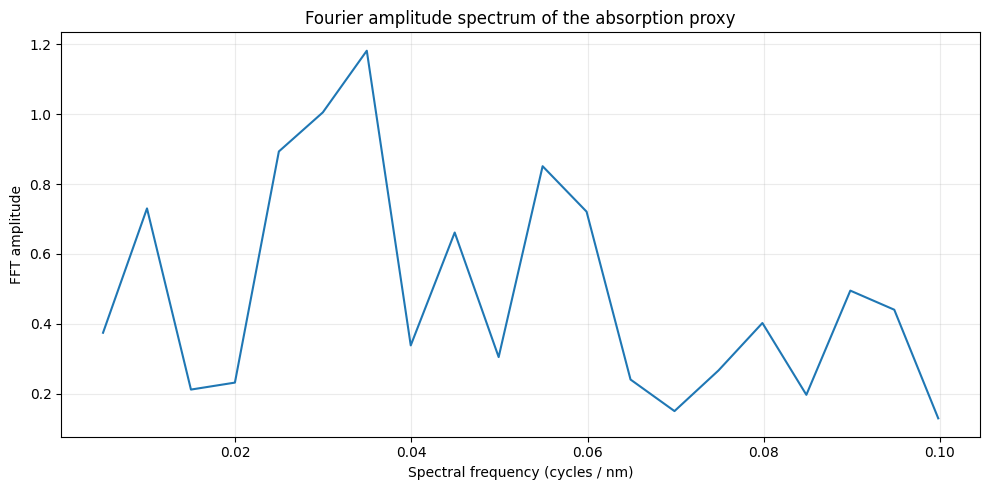

In [18]:
delta = np.diff(ch4_wavelengths)

print(f"Δλ median={np.median(delta):.6f} nm, "
      f"range={delta.min():.6f}-{delta.max():.6f} nm")

delta_lambda = float(np.median(delta))

# Absorption proxy from one continuum-removed spectrum
absorption = 1.0 - Xp_ratio[0]

signal = np.nan_to_num(absorption - np.nanmean(absorption))

fft_vals = np.fft.rfft(signal)
freq = np.fft.rfftfreq(len(signal), d=delta_lambda)
amplitude = np.abs(fft_vals)

plt.figure(figsize=(10, 5))
plt.plot(freq[1:], amplitude[1:])
plt.title("Fourier amplitude spectrum of the absorption proxy")
plt.xlabel("Spectral frequency (cycles / nm)")
plt.ylabel("FFT amplitude")
plt.grid(alpha=.25)
plt.tight_layout()
plt.show()

## 10. PCA / Covariance Analysis — All Sampled Spectra

### English

PCA is applied to sampled spectra to identify dominant spectral variability and redundancy.

After centering, $X_c = X - \mu$, the covariance matrix is

$$
C = \frac{1}{N-1}X_c^T X_c
$$

and PCA solves

$$
Cv_i = \lambda_i v_i.
$$

The eigenvectors $v_i$ represent the principal spectral directions, while $\lambda_i$ represents their variance. PCA is used as a **diagnostic tool**, not as a requirement for ML model.

Two preprocessing variants are compared.

### Modification 1 — Log-Radiance

Under

$$
L(\lambda) \approx A\,S(\lambda)\,T(\lambda),
$$

the logarithm gives

$$
\ln L = \ln A + \ln S + \ln T.
$$

This converts multiplicative factors into additive terms but does **not remove** albedo or illumination effects.

### Modification 2 — Continuum Removal

The local continuum $C(\lambda)$ is estimated outside the CH₄ absorption window.

$$
R(\lambda) = \frac{L(\lambda)}{C(\lambda)}
$$

and

$$
A(\lambda) = -\ln\left(\frac{L(\lambda)}{C(\lambda)}\right).
$$

This removes the slowly varying local baseline and emphasizes localized absorption structure. It reduces, but does not completely eliminate, albedo, illumination, or atmospheric effects.

---

## 10. PCA / 共分散解析 — 全サンプルスペクトル

### 日本語

PCAをサンプルスペクトルに適用し、主要なスペクトル変動と冗長性を調べる。

中心化後、$X_c = X - \mu$ とすると、共分散行列は

$$
C = \frac{1}{N-1}X_c^T X_c
$$

であり、PCAは

$$
Cv_i = \lambda_i v_i
$$

を解く。

固有ベクトル $v_i$ は主要なスペクトル方向、固有値 $\lambda_i$ は各成分の分散を表す。PCAは**診断・解析用**であり、ML modelに必須ではない。

2種類の前処理を比較する。

### Modification 1 — Log-Radiance / 対数放射輝度

$$
L(\lambda) \approx A\,S(\lambda)\,T(\lambda)
$$

に対して、

$$
\ln L = \ln A + \ln S + \ln T.
$$

乗算要因を加算項に変換するが、アルベドや照明の影響そのものを**除去するものではない**。

### Modification 2 — Continuum Removal / Continuum除去

CH₄吸収窓の外側から局所continuum $C(\lambda)$ を推定する。

$$
R(\lambda) = \frac{L(\lambda)}{C(\lambda)}
$$

および

$$
A(\lambda) = -\ln\left(\frac{L(\lambda)}{C(\lambda)}\right).
$$

緩やかに変化する局所ベースラインを除去し、局所的な吸収構造を強調する。アルベド・照明・大気効果を完全には除去せず、その影響を低減する。



log-radiance
Explained variance: [0.87124306 0.06535011 0.02119866 0.00585298 0.0036454 ]
Cumulative: [0.87124306 0.9365932  0.95779186 0.96364486 0.9672903 ]


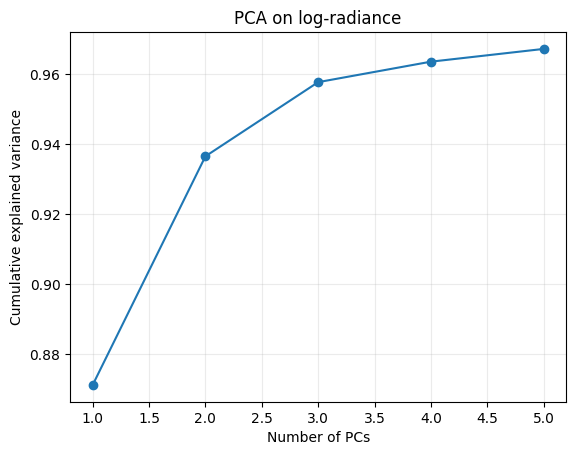


continuum-removed ratio
Explained variance: [9.8775816e-01 5.5633280e-03 1.4241225e-03 9.0887037e-04 4.2465856e-04]
Cumulative: [0.98775816 0.9933215  0.9947456  0.99565446 0.99607915]


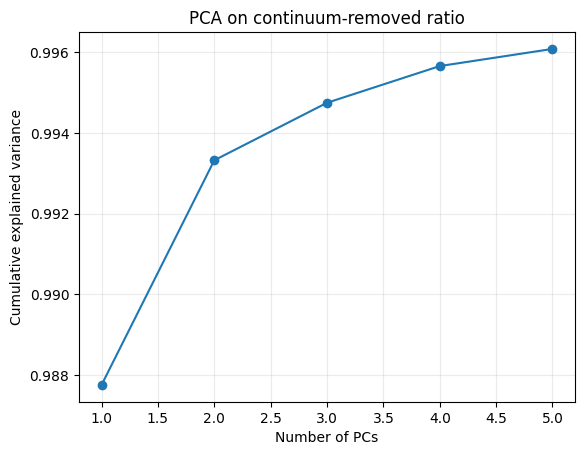

In [19]:
# ---  PCA - Diagnostics ---

PCA_RANDOM_STATE = 0

def run_pca_diagnostics(X, label, n_components=5):
    n_components = min(n_components, X.shape[0], X.shape[1])
    pca = PCA(n_components=n_components, random_state=PCA_RANDOM_STATE)
    scores = pca.fit_transform(X)
    cumvar = np.cumsum(pca.explained_variance_ratio_)

    print(f"\n{label}")
    print("Explained variance:", pca.explained_variance_ratio_)
    print("Cumulative:", cumvar)

    plt.plot(np.arange(1, len(cumvar) + 1), cumvar, marker="o")
    plt.xlabel("Number of PCs")
    plt.ylabel("Cumulative explained variance")
    plt.title(f"PCA on {label}")
    plt.grid(alpha=.25)
    plt.show()

    return pca, scores

# Modification 1 — log-radiance
Xp_log = np.log(Xp)
Xp_log_centered = Xp_log - Xp_log.mean(axis=1, keepdims=True)
pca_log, _ = run_pca_diagnostics(Xp_log_centered, "log-radiance")

# Modification 2 — continuum-removed ratio
pca_ratio, scores_ratio = run_pca_diagnostics(Xp_ratio, "continuum-removed ratio")

### Interpreting the results

PC1 shows how much of the spectral variation is explained by the first principal component.

* **Log-radiance:** A high PC1 means that most spectral variation follows one dominant pattern, often related to broadband effects such as albedo and illumination.
* **Continuum-removed ratio:** Continuum removal reduces the broadband spectral shape. PCA then shows how the remaining spectral variation is organized.
* A high PC1 after continuum removal means that the remaining spectra still share a similar spectral pattern. It does **not** mean that continuum removal failed.

The comparison is diagnostic: it shows how preprocessing changes the structure of spectral variability.

---

### 結果の解釈

PC1は、スペクトル変動のうち第1主成分で説明できる割合を示す。

* **Log-radiance：** PC1が高い場合、多くのスペクトル変動が1つの主要なパターンに集中している。これはアルベドや照明などの広帯域効果による場合がある。
* **Continuum-removed ratio：** Continuum除去によって広帯域のスペクトル形状が低減される。その後、残ったスペクトル変動がどのように構成されているかをPCAで確認する。
* Continuum除去後にPC1が高くても、**continuum除去が失敗したことを意味しない**。残ったスペクトルが類似したパターンを持っていることを示す。

この比較は診断目的であり、前処理によってスペクトル変動の構造がどのように変化したかを確認する。


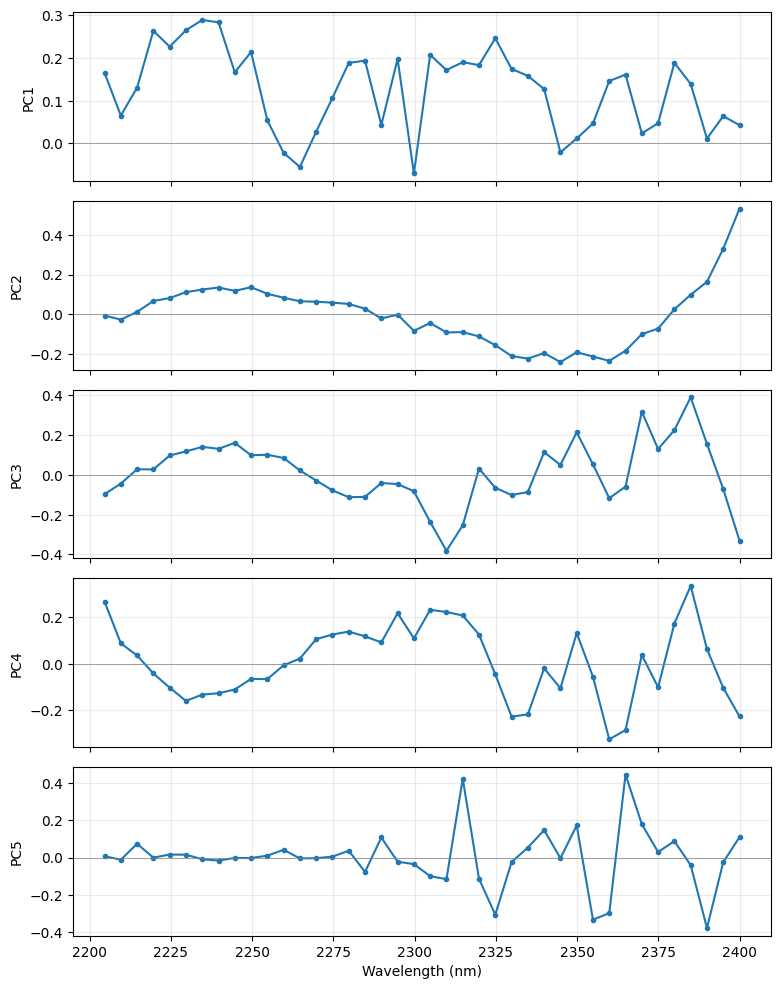

In [20]:
# continuum-removed ratio PCA components plotted against wavelengths in the CH4-sensitive region

fig, axes = plt.subplots(
    len(pca_ratio.components_),
    1,
    figsize=(8, 2 * len(pca_ratio.components_)),
    sharex=True
)

for i, ax in enumerate(axes):
    ax.plot(ch4_wavelengths, pca_ratio.components_[i], marker=".")
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.set_ylabel(f"PC{i+1}")
    ax.grid(alpha=.25)

axes[-1].set_xlabel("Wavelength (nm)")
plt.tight_layout()
plt.show()

PC1 is monoton descending without pick, so appear so be albedo effect, so is needed a normalization or?

## 11. CH₄ Unit Absorption Spectrum & Spectral Similarity

### English

The `*_ch4_ua.txt` file is treated as a **modeled CH₄ unit absorption spectrum**, not as measured ground truth.

We extract its wavelength and absorption signal, verify wavelength overlap with AVIRIS-NG, and interpolate the reference spectrum onto the AVIRIS-NG wavelength grid. The resulting `UA_interpolated` provides a **CH₄ reference spectral signature** for comparison.

$$
\text{UA spectrum}
\;\rightarrow\;
\text{wavelength alignment}
\;\rightarrow\;
\boxed{\text{CH}_4\text{ reference }UA_{\text{interpolated}}}
$$

It is used for spectral comparison, not as an independent measurement of atmospheric CH₄ concentration.

### Spectral Similarity Baseline

The measured spectrum $x$ is compared with the CH₄ reference spectrum $s$ using two simple baselines.

**Cosine similarity** measures overall spectral shape similarity:

$$
\cos\theta =
\frac{x^T s}{\lVert x\rVert \lVert s\rVert}
$$

**Pearson correlation** measures similarity in the wavelength-by-wavelength variation pattern:

$$
\rho =
\frac{\sum_i (x_i-\bar{x})(s_i-\bar{s})}
{\sqrt{\sum_i (x_i-\bar{x})^2}
\sqrt{\sum_i (s_i-\bar{s})^2}}
$$

These metrics provide **baseline spectral similarity scores** before applying more advanced retrieval or machine-learning methods.

---

## 11. CH₄ 単位吸収スペクトルとスペクトル類似度

### 日本語

`*_ch4_ua.txt` ファイルは、**モデル化された CH₄ 単位吸収スペクトル**として扱い、実測された ground truth とはみなさない。

波長と吸収信号を抽出し、AVIRIS-NG との波長範囲の重なりを確認した後、AVIRIS-NG の波長グリッドへ補間する。これにより、比較に使用する **CH₄ 参照スペクトル `UA_interpolated`** を作成する。

$$
\text{UA spectrum}
\;\rightarrow\;
\text{wavelength alignment}
\;\rightarrow\;
\boxed{\text{CH}_4\text{ reference }UA_{\text{interpolated}}}
$$

これはスペクトル比較に使用するものであり、大気中 CH₄ 濃度の独立した実測値ではない。

### スペクトル類似度のベースライン

測定スペクトル $x$ と CH₄ 参照スペクトル $s$ を、2つの基本的な指標で比較する。

**コサイン類似度**は、スペクトル全体の形状の類似性を評価する。

$$
\cos\theta =
\frac{x^T s}{\lVert x\rVert \lVert s\rVert}
$$

**ピアソン相関係数**は、波長ごとの変化パターンの類似性を評価する。

$$
\rho =
\frac{\sum_i (x_i-\bar{x})(s_i-\bar{s})}
{\sqrt{\sum_i (x_i-\bar{x})^2}
\sqrt{\sum_i (s_i-\bar{s})^2}}
$$

これらの指標は、高度な retrieval や機械学習を適用する前の**スペクトル類似度のベースライン**として使用する。


In [21]:
# Load the modeled CH4 unit absorption spectrum
ua = np.loadtxt(UA_FILE)

if ua.ndim != 2 or ua.shape[1] < 3:
    raise ValueError(f"Unexpected UA file shape: {ua.shape}. Expected at least 3 columns.")

# Extract wavelength and UA signal
ua_wavelength = ua[:, 1].astype(np.float32)
ua_signal = ua[:, 2].astype(np.float32)

# Validate input data
if not np.isfinite(ua_wavelength).all():
    raise ValueError("UA wavelength contains NaN or Inf.")

if not np.isfinite(ua_signal).all():
    raise ValueError("UA signal contains NaN or Inf.")

if not np.all(np.diff(ua_wavelength) > 0):
    raise ValueError("UA wavelengths must be strictly increasing.")

print("UA columns:")
print("  Column 0: index")
print("  Column 1: wavelength [nm]")
print("  Column 2: UA signal (CH4 unit absorption spectrum)")
print()
print(f"UA shape: {ua.shape}")
print(f"UA wavelength: {ua_wavelength.min():.2f}-{ua_wavelength.max():.2f} nm")
print(f"UA signal: min={ua_signal.min():.4f}, max={ua_signal.max():.4f}, std={ua_signal.std():.4f}")


# Check wavelength overlap
overlap_min = max(ua_wavelength.min(), ch4_wavelengths.min())
overlap_max = min(ua_wavelength.max(), ch4_wavelengths.max())

if overlap_min >= overlap_max:
    raise ValueError("No wavelength overlap between UA and AVIRIS.")

print(f"AVIRIS CH4 range: {ch4_wavelengths.min():.2f}-{ch4_wavelengths.max():.2f} nm")
print(f"Wavelength overlap: {overlap_min:.2f}-{overlap_max:.2f} nm")

# Interpolate UA onto AVIRIS wavelength grid
UA_interpolated = np.interp(
    ch4_wavelengths,
    ua_wavelength,
    ua_signal
).astype(np.float32)

# Validate interpolated spectrum
if not np.isfinite(UA_interpolated).all():
    raise ValueError("UA_interpolated contains NaN or Inf.")

if UA_interpolated.std() == 0:
    raise ValueError("UA_interpolated is constant.")

print(f"UA_interpolated: min={UA_interpolated.min():.4f}, "
      f"max={UA_interpolated.max():.4f}, "
      f"std={UA_interpolated.std():.4f}")

UA columns:
  Column 0: index
  Column 1: wavelength [nm]
  Column 2: UA signal (CH4 unit absorption spectrum)

UA shape: (212, 3)
UA wavelength: 1443.29-2500.12 nm
UA signal: min=-1.2483, max=0.0000, std=0.2772
AVIRIS CH4 range: 2204.60-2399.94 nm
Wavelength overlap: 2204.60-2399.94 nm
UA_interpolated: min=-1.2483, max=-0.0992, std=0.2984


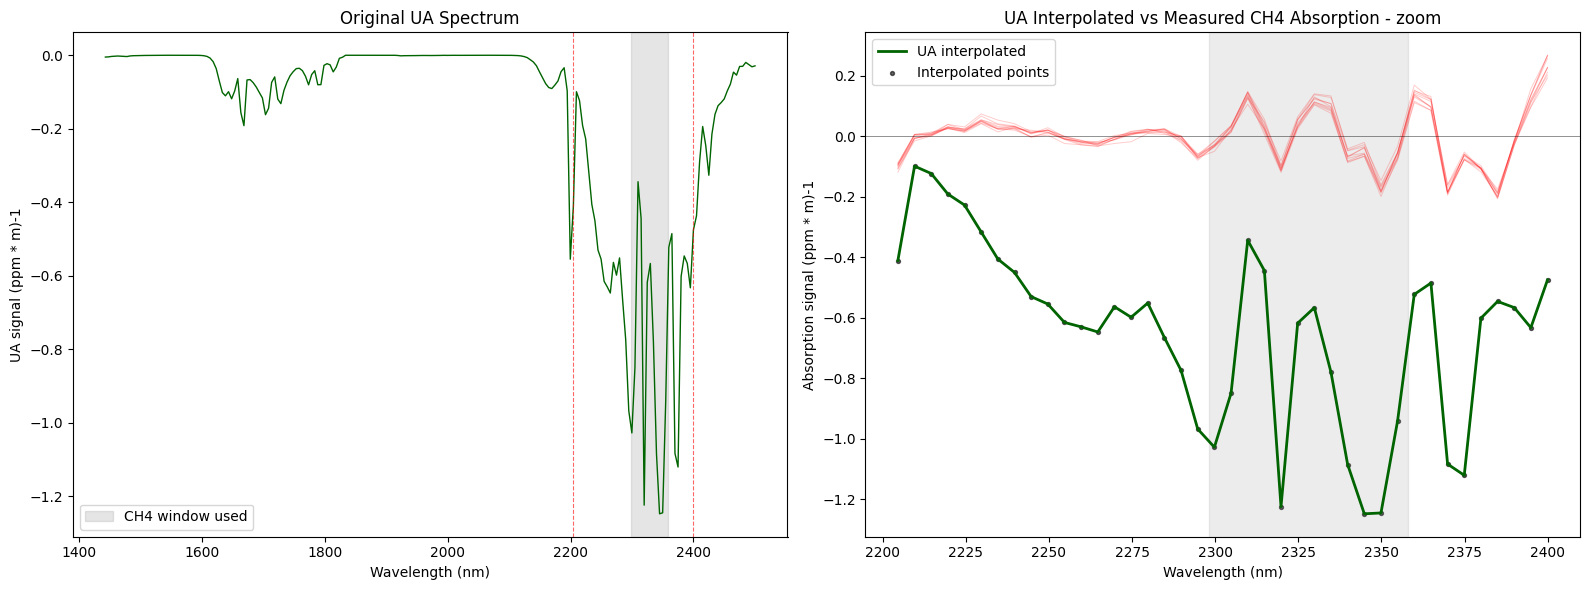

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Original UA spectrum
ax = axes[0]
ax.plot(ua_wavelength, ua_signal, color='darkgreen', lw=1)
ax.axvspan(CH4_ABS_MIN, CH4_ABS_MAX, color='gray', alpha=0.2, label='CH4 window used')
ax.axvline(overlap_min, color='red', ls='--', lw=0.8, alpha=0.6)
ax.axvline(overlap_max, color='red', ls='--', lw=0.8, alpha=0.6)
ax.set(title="Original UA Spectrum", xlabel="Wavelength (nm)",
       ylabel="UA signal (ppm * m)-1")
ax.legend()

# 2. UA interpolated vs measured absorption
ax = axes[1]
ax.plot(ch4_wavelengths, UA_interpolated,
        color='darkgreen', lw=2, label='UA interpolated')

# Interpolated points
ax.scatter(ch4_wavelengths, UA_interpolated,
           color='black', s=8, alpha=0.6, label='Interpolated points')

idx_pos_plot = np.where(ref_valid > 0)[0]
if len(idx_pos_plot) > 0:
    rng = np.random.default_rng(0)
    for i in rng.choice(idx_pos_plot, min(10, len(idx_pos_plot)), replace=False):
        ax.plot(ch4_wavelengths, Xp_ratio[i] - 1,
                color='red', alpha=0.2, lw=0.7)

ax.axhline(0, color='black', lw=0.6, alpha=0.5)
ax.axvspan(CH4_ABS_MIN, CH4_ABS_MAX, color='gray', alpha=0.15)
ax.set(title="UA Interpolated vs Measured CH4 Absorption - zoom",
       xlabel="Wavelength (nm)",
       ylabel="Absorption signal (ppm * m)-1")
ax.legend()

plt.tight_layout()
plt.show()

In [23]:
print("UA Interpolated:")
print("  min =", UA_interpolated.min())
print("  max =", UA_interpolated.max())
print("  std =", UA_interpolated.std())
print("  norm =", np.linalg.norm(UA_interpolated))

print("wavelength:")
print("  min =", wavelengths.min())
print("  max =", wavelengths.max())
print("  n =", len(wavelengths))

UA Interpolated:
  min = -1.2483096
  max = -0.099212125
  std = 0.29839095
  norm = 4.4862337
wavelength:
  min = 376.44
  max = 2500.12
  n = 425


### UA Reference Spectrum

The UA file contains a **non-zero CH₄ reference spectral signature**.

- Wavelength range: **1443.29–2500.12 nm**
- Signal range: **−1.2483 to 0**
- AVIRIS overlap: **2204.6–2399.94 nm**
- The signal is interpolated onto the AVIRIS wavelength grid to create the `UA_interpolate` spectrum.

> The UA spectrum is the **CH₄ signature we are looking for**, not a CH₄ detection in the AVIRIS image.

### UA基準スペクトル

UAファイルには、**ゼロではないCH₄の基準スペクトル**が含まれています。

- 波長範囲: **1443.29–2500.12 nm**
- 信号範囲: **−1.2483～0**
- AVIRISとの重複範囲: **2204.6–2399.94 nm**
- AVIRISの波長グリッドに補間し、`UA_interpolate`スペクトルを作成します。

> UAスペクトルは**検出したCH₄ではなく、検出対象となるCH₄の基準スペクトル**です。

## 14. ML Dataset Construction

### English

The ML dataset is constructed from the already processed CH₄-region spectra.

The input features are the continuum-removed spectra:

$$
X_i =
\left[
R_i(\lambda_1),\ldots,R_i(\lambda_B)
\right]
$$

where each row represents one image pixel.

The corresponding target value is the JPL matched-filter result:

$$
y_i = MF_i
$$

The matched-filter value is retained as a continuous reference value. The binary CH₄/background label is created separately in the next section.

The original spatial coordinates $(r,c)$ are also retained so that the pixels can later be separated spatially and mapped back to the image.

---

## 14. MLデータセットの構築

### 日本語

MLデータセットは、すでに処理されたCH₄領域のスペクトルから構築する。

入力特徴量には、continuum除去後のスペクトルを使用する。

$$
X_i =
\left[
R_i(\lambda_1),\ldots,R_i(\lambda_B)
\right]
$$

各行は1つの画像画素を表す。

対応するターゲット値には、JPLのmatched-filter結果を使用する。

$$
y_i = MF_i
$$

matched-filter値は連続値として保持し、CH₄/backgroundの二値ラベルは次のセクションで別途作成する。

また、元の空間座標 $(r,c)$ も保持し、後で空間的にtrain/testを分離し、結果を画像へ戻せるようにする。


In [24]:
# ------------------------------------------------------------
# ML dataset
# ------------------------------------------------------------
#Modelul învață să reproducă eticheta MF, nu să găsească metan independent pentru identificare metan in viitoare imagini

# Use spectra and coordinates from the same filtering step
X = Xp_ratio
rows = rows_valid
cols = cols_valid

# Corresponding JPL matched-filter values
y = ref[rows, cols].astype(np.float32)

# Keep only finite targets
valid = np.isfinite(y)

X = X[valid]
y = y[valid]
rows = rows[valid]
cols = cols[valid]

print("=== ML DATASET ===")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Coordinates: {len(rows):,}")
print(f"X finite: {np.isfinite(X).all()}")
print(f"y finite: {np.isfinite(y).all()}")
print(f"y min/max: {y.min():.4f} / {y.max():.4f}")

=== ML DATASET ===
X shape: (2356120, 40)
y shape: (2356120,)
Coordinates: 2,356,120
X finite: True
y finite: True
y min/max: 0.0000 / 14208.3789


In [25]:
# Albedo quality filter
alb_values = alb[rows, cols]

alb_lo, alb_hi = np.nanpercentile(alb_values, [2, 98])
albedo_ok = (
    np.isfinite(alb_values) &
    (alb_values >= alb_lo) &
    (alb_values <= alb_hi)
)

X = X[albedo_ok]
y = y[albedo_ok]
rows = rows[albedo_ok]
cols = cols[albedo_ok]

print("\n=== AFTER ALBEDO FILTER ===")
print(f"Albedo range: {alb_lo:.4f} - {alb_hi:.4f}")
print(f"Remaining pixels: {len(y):,}")
print(f"X shape: {X.shape}")


=== AFTER ALBEDO FILTER ===
Albedo range: 0.3005 - 1.7898
Remaining pixels: 2,261,875
X shape: (2261875, 40)


## 15. CH₄ / Background Labels

### English

The JPL matched-filter values are highly zero-inflated, with a large population of pixels near zero.

Therefore, the classification threshold is calculated only from positive matched-filter responses:

$$
T = Q_{0.98}(y \mid y>0)
$$

The binary pseudo-label is then:

$$
y_i^{class} =
\begin{cases}
1, & y_i \geq T\\
0, & y_i < T
\end{cases}
$$

Class 1 represents strong positive CH₄ matched-filter responses, while class 0 represents the remaining pixels.

These are retrieval-derived pseudo-labels, not independent ground-truth labels.

---

## 15. CH₄ / Backgroundラベル

### 日本語

JPLのmatched-filter値はゼロ付近の画素が非常に多いため、分布はzero-inflatedである。

したがって、分類しきい値はすべての値からではなく、正のmatched-filter応答だけから計算する。

$$
T = Q_{0.98}(y \mid y>0)
$$

二値のpseudo-labelは次のように定義する。

$$
y_i^{class} =
\begin{cases}
1, & y_i \geq T\\
0, & y_i < T
\end{cases}
$$

Class 1は強い正のCH₄ matched-filter応答を表し、Class 0はそれ以外の画素を表す。

これらはretrievalから得られたpseudo-labelであり、独立したground truthではない。


Nu folosim np.percentile(y, 98) direct, deoarece y conține foarte multe valori zero.

```text
MF values (ppm·m), one per pixel
        │
        ▼
 ┌──────────────────────────┐
 │ keep only y > 0          │──►  positive_y
 └──────────────────────────┘
        │
        ▼
 ┌──────────────────────────┐
 │ T = 98th percentile      │──►  label threshold (ppm·m)
 │     of positive_y        │
 └──────────────────────────┘
        │
        ▼   applied to ALL pixels (not only positive ones)
 ┌──────────────────────────┐
 │ y ≥ T  →  1  (CH₄)       │
 │ y <  T →  0  (background)│──►  y_class
 └──────────────────────────┘

 y < 0        0        T                         max
 ├────────────┼────────┼──────────────────────────┤
 │ background │background│         CH₄ (≈2% of positives)
 │  (class 0) │(class 0)│          (class 1)
```

In [26]:
# ------------------------------------------------------------
# CH4 / background labels
# ------------------------------------------------------------

positive_y = y[y > 0]

if len(positive_y) == 0:
    raise ValueError("No positive CH4 reference values found.")

threshold = np.percentile(positive_y, 98)

y_class = (y >= threshold).astype(np.uint8)

print("=== ML LABELS ===")
print(f"Positive MF samples: {len(positive_y):,}")
print(f"Label threshold: {threshold:.4f} ppm·m")
print(f"Background: {(y_class == 0).sum():,}")
print(f"CH4: {(y_class == 1).sum():,}")
print(f"CH4 fraction: {y_class.mean():.4%}")

=== ML LABELS ===
Positive MF samples: 132,445
Label threshold: 1388.7312 ppm·m
Background: 2,259,226
CH4: 2,649
CH4 fraction: 0.1171%


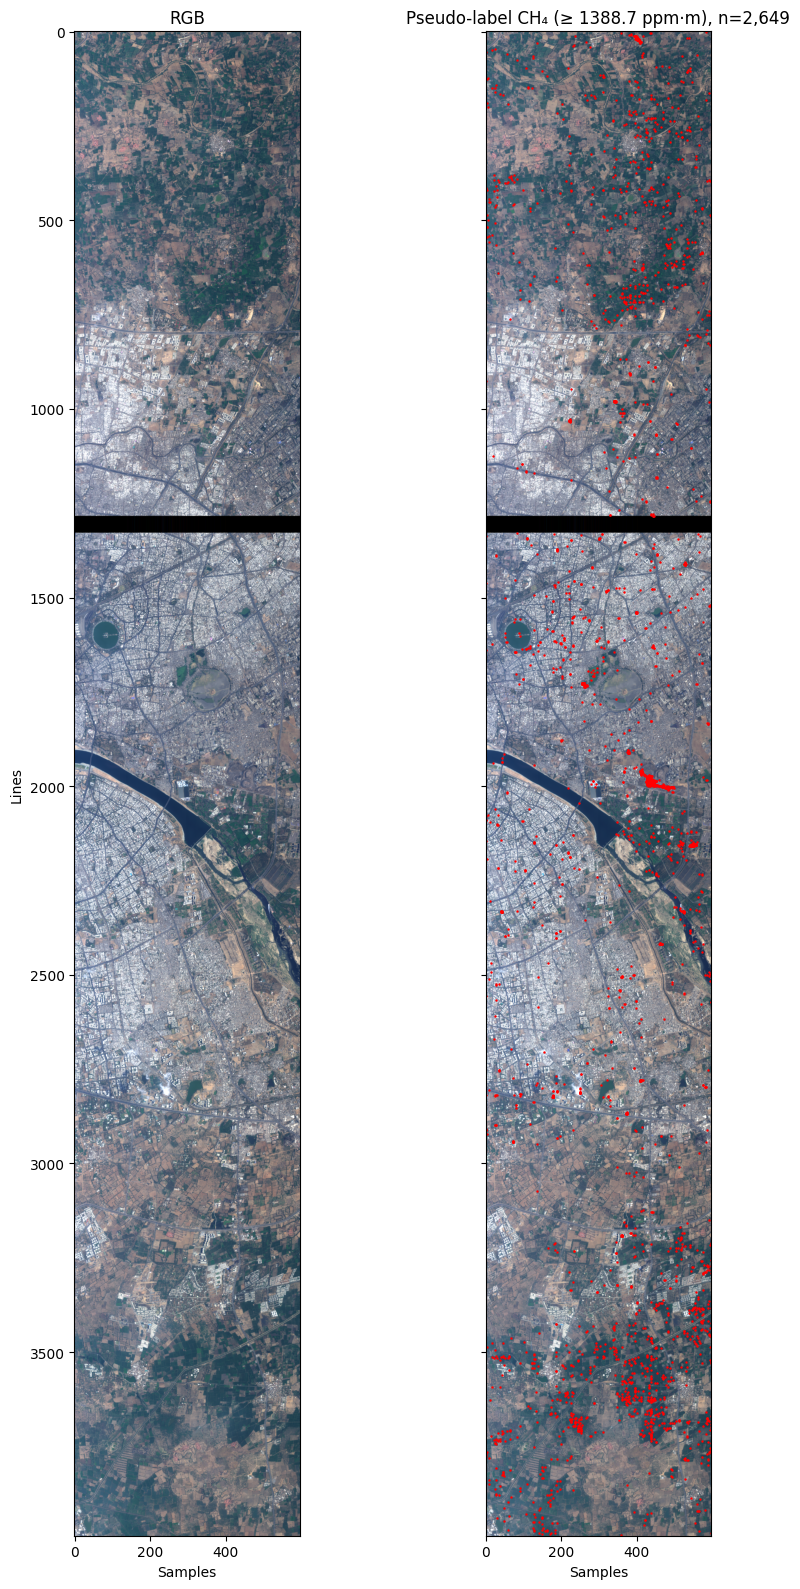

In [27]:
pos = y_class == 1

fig, axes = plt.subplots(1, 2, figsize=(10, 16), sharey=True)
axes[0].imshow(rgb_reconstructed)
axes[0].set_title("RGB")

axes[1].imshow(rgb_reconstructed)
axes[1].scatter(cols[pos], rows[pos], s=3, c="red", linewidths=0)
axes[1].set_title(f"Pseudo-label CH₄ (≥ {threshold:.1f} ppm·m), n={pos.sum():,}")

for ax in axes:
    ax.set_xlabel("Samples")
axes[0].set_ylabel("Lines")
plt.tight_layout()
plt.savefig(FIG_DIR / "s15_pseudo_labels.png", dpi=150)
plt.show()

Celula face o verificare fizică: dacă pixelii etichetați „CH₄" au într-adevăr în spectru forma absorbției metanului, sau doar au fost marcați de MF fără să aibă o semnătură reală.

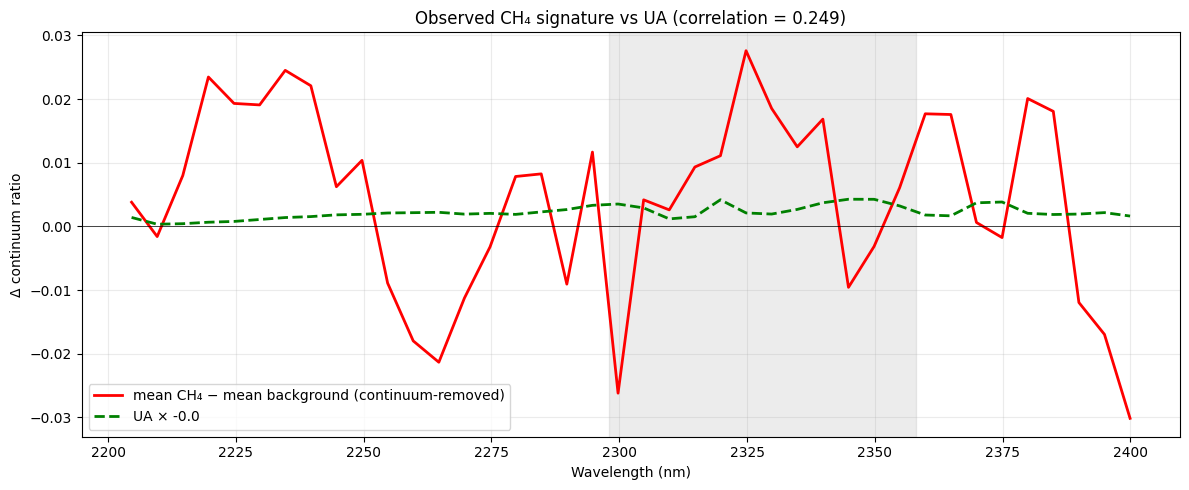

Correlation diff vs UA: 0.249
UA scale: -0.0 | mean MF difference: 1730.6 ppm·m


In [28]:
ua_ref = UA_interpolated
mean_ch4 = X[y_class == 1].mean(axis=0)
mean_bg  = X[y_class == 0].mean(axis=0)
diff = mean_ch4 - mean_bg

# least-squares scaling: diff ≈ scale * UA
scale = float(diff @ ua_ref / (ua_ref @ ua_ref))
corr  = np.corrcoef(diff, ua_ref)[0, 1]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(ch4_wavelengths, diff, "r", lw=2, label="mean CH₄ − mean background (continuum-removed)")
ax.plot(ch4_wavelengths, scale * ua_ref, "g--", lw=2, label=f"UA × {scale:.1f}")
ax.axhline(0, color="k", lw=0.5)
ax.axvspan(CH4_ABS_MIN, CH4_ABS_MAX, color="gray", alpha=0.15)
ax.set(xlabel="Wavelength (nm)", ylabel="Δ continuum ratio",
       title=f"Observed CH₄ signature vs UA (correlation = {corr:.3f})")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(FIG_DIR / "s11_diff_vs_ua.png", dpi=150)
plt.show()

print(f"Correlation diff vs UA: {corr:.3f}")
print(f"UA scale: {scale:.1f} | mean MF difference: {y[y_class==1].mean() - y[y_class==0].mean():.1f} ppm·m")

## 16. Spatial Train/Test Split

### English

Hyperspectral pixels are spatially correlated. Therefore, randomly splitting individual pixels can place neighboring pixels in both the training and test sets.

To reduce this spatial leakage, the image is divided into spatial blocks and complete blocks are assigned to either training or test data.

The spatial coordinates are retained throughout the split.

---

## 16. 空間的Train/Test分割

### 日本語

ハイパースペクトル画像の画素は空間的に相関している。そのため、画素をランダムに分割すると、隣接画素がtrainとtestの両方に入る可能性がある。

このような空間的リークを低減するため、画像を空間ブロックに分割し、各ブロック全体をtrainまたはtestのどちらかに割り当てる。

分割後も元の空間座標を保持する。



```text
Image divided into 20×20 pixel blocks; whole blocks are assigned at random:

 ┌────┬────┬────┬────┬────┐
 │ TR │ TR │ TE │ TR │ TR │
 ├────┼────┼────┼────┼────┤
 │ TR │ TE │ TR │ TR │ TE │     TR = train (80%)
 ├────┼────┼────┼────┼────┤     TE = test  (20%)
 │ TR │ TR │ TR │ TE │ TR │
 └────┴────┴────┴────┴────┘
 ```

!! Furthet implementations => Validation data

In [ ]:
# ------------------------------------------------------------
# Section 16: Spatial train/test split
# ------------------------------------------------------------

BLOCK_SIZE = 20  # size of the spatial blocks in pixels
TEST_FRACTION = 0.20  # fraction of blocks to use for testing
RANDOM_STATE = 42 # random state for reproducibility

block_rows = rows // BLOCK_SIZE
block_cols = cols // BLOCK_SIZE

groups = block_rows * (cols.max() // BLOCK_SIZE + 1) + block_cols

rng = np.random.default_rng(RANDOM_STATE)

unique_groups = np.unique(groups)
rng.shuffle(unique_groups)

n_test_groups = max(1, int(len(unique_groups) * TEST_FRACTION))
test_groups = set(unique_groups[:n_test_groups])

#test_mask = np.array([g in test_groups for g in groups])
test_mask = np.isin(groups, list(test_groups))
train_mask = ~test_mask

X_train = X[train_mask]
X_test = X[test_mask]

y_train = y_class[train_mask]
y_test = y_class[test_mask]

print("=== SPATIAL SPLIT ===")
print(f"Block size: {BLOCK_SIZE} pixels")
print(f"Train: {len(y_train):,}")
print(f"Test : {len(y_test):,}")
print(f"Train CH4: {y_train.sum():,}")
print(f"Test CH4 : {y_test.sum():,}")

=== SPATIAL SPLIT ===
Block size: 20 pixels
Train: 1,808,926
Test : 452,949
Train CH4: 2,199
Test CH4 : 450


Verifici vizual cum arată împărțirea train/test în imagine și unde cad pixelii CH₄ față de ea. Celula nu calculează nimic nou, doar desenează ce a decis Sec. 16.

Ce desenează
Fundal albastru deschis = pixeli de train, portocaliu deschis = pixeli de test, alb = pixeli nefolosiți (nodata sau scoși de filtre).
Puncte albastre = pixeli CH₄ din train, puncte roșii = pixeli CH₄ din test.

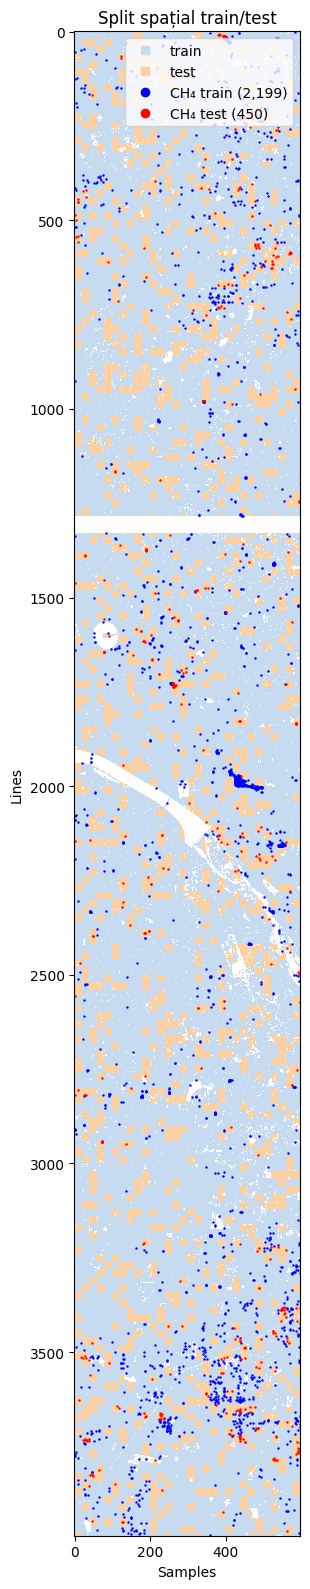

In [30]:
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D

split_map = np.zeros(ref.shape, dtype=np.uint8)
split_map[rows[train_mask], cols[train_mask]] = 1
split_map[rows[test_mask],  cols[test_mask]]  = 2

cmap = ListedColormap(["white", "#c6dbef", "#fdd0a2"])  # none / train / test

fig, ax = plt.subplots(figsize=(6, 16))
ax.imshow(split_map, cmap=cmap, vmin=0, vmax=2, interpolation="nearest")

pos = y_class == 1
ax.scatter(cols[pos & train_mask], rows[pos & train_mask], s=3, c="blue", linewidths=0)
ax.scatter(cols[pos & test_mask],  rows[pos & test_mask],  s=3, c="red",  linewidths=0)

ax.legend(handles=[
    Line2D([], [], marker="s", ls="", color="#c6dbef", label="train"),
    Line2D([], [], marker="s", ls="", color="#fdd0a2", label="test"),
    Line2D([], [], marker="o", ls="", color="blue", label=f"CH₄ train ({y_train.sum():,})"),
    Line2D([], [], marker="o", ls="", color="red",  label=f"CH₄ test ({y_test.sum():,})"),
], loc="upper right")
ax.set(title="Split spațial train/test", xlabel="Samples", ylabel="Lines")
plt.tight_layout()
plt.savefig(FIG_DIR / "s16_split_map.png", dpi=150)
plt.show()

## 17. LightGBM

### English

A LightGBM binary classifier is trained to distinguish CH₄ candidate pixels from background pixels.

The input is the continuum-removed CH₄-region spectrum, and the target is the retrieval-derived binary pseudo-label.

$$
X_{\mathrm{spectral}}
\rightarrow
\mathrm{LightGBM}
\rightarrow
P(\mathrm{CH}_4)
$$

The model is intended as a fast detector for future hyperspectral images after the same preprocessing steps.

---

## 17. LightGBM

### 日本語

LightGBMの二値分類器を使用して、CH₄候補画素と背景画素を分類する。

入力はcontinuum除去後のCH₄領域スペクトルであり、targetにはretrievalから作成した二値pseudo-labelを使用する。

$$
X_{\mathrm{spectral}}
\rightarrow
\mathrm{LightGBM}
\rightarrow
P(\mathrm{CH}_4)
$$

同じ前処理を行った将来のハイパースペクトル画像に対して、高速なCH₄検出器として使用することを目的とする。


In [ ]:
# ------------------------------------------------------------
# LightGBM
# ------------------------------------------------------------

from lightgbm import LGBMClassifier

n_negative = np.sum(y_train == 0) # background samples
n_positive = np.sum(y_train == 1) # CH4 samples

scale_pos_weight = n_negative / max(n_positive, 1)

model = LGBMClassifier(
    objective="binary",
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

model.fit(X_train, y_train)

prob_test = model.predict_proba(X_test)[:, 1]
pred_test = (prob_test >= 0.5).astype(np.uint8)

print("=== LIGHTGBM ===")
print(f"Features: {X_train.shape[1]}")
print(f"Training samples: {len(y_train):,}")
print(f"Positive samples: {y_train.sum():,}")
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

[LightGBM] [Info] Number of positive: 2199, number of negative: 1806727
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.139835 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10200
[LightGBM] [Info] Number of data points in the train set: 1808926, number of used features: 40
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001216 -> initscore=-6.711269
[LightGBM] [Info] Start training from score -6.711269
=== LIGHTGBM ===
Features: 40
Training samples: 1,808,926
Positive samples: 2,199
scale_pos_weight: 821.61


NEXT: Validation TEST

## 18. Model Evaluation

### English

The trained classifier is evaluated on spatially separated test pixels.

The main metrics are:

* Precision
* Recall
* F1-score
* ROC-AUC
* Confusion matrix

These metrics evaluate how well the ML model reproduces the retrieval-derived CH₄/background labels.

The evaluation does not represent independent physical validation because the labels originate from the same JPL retrieval product.

---

## 18. モデル評価

### 日本語

学習した分類器を、空間的に分離されたtest画素に対して評価する。

主な評価指標は次のとおりである。

* Precision
* Recall
* F1-score
* ROC-AUC
* Confusion matrix

これらの指標によって、MLモデルがretrievalから作成されたCH₄/backgroundラベルをどの程度再現できるかを評価する。

ただし、ラベルは同じJPL retrieval productから作成されているため、この評価は独立した物理的ground truthによる検証ではない。


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

  Background     0.9997    0.8689    0.9297    452499
         CH4     0.0056    0.7444    0.0111       450

    accuracy                         0.8688    452949
   macro avg     0.5027    0.8067    0.4704    452949
weighted avg     0.9987    0.8688    0.9288    452949

ROC-AUC: 0.7710


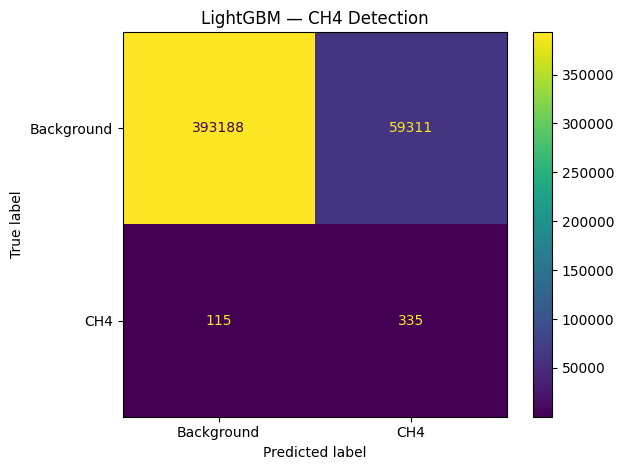

In [32]:
# ------------------------------------------------------------
# Evaluation
# ------------------------------------------------------------

print("=== CLASSIFICATION REPORT ===")
print(
    classification_report(
        y_test,
        pred_test,
        target_names=["Background", "CH4"],
        digits=4
    )
)

roc_auc = roc_auc_score(y_test, prob_test)

print(f"ROC-AUC: {roc_auc:.4f}")

cm = confusion_matrix(y_test, pred_test)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Background", "CH4"]
)

disp.plot()
plt.title("LightGBM — CH4 Detection")
plt.tight_layout()
plt.show()

**Interpretation**

The test set is extremely imbalanced: 450 CH₄ pixels versus 452,499 background pixels (0.1%). At a probability threshold of 0.5, the model finds about 74% of the CH₄ pixels (recall = 0.744), but only 0.6% of its CH₄ predictions are correct (precision = 0.006), so false alarms outnumber true detections by roughly 170 to 1. Accuracy (0.873) and the weighted average are dominated by the background class and are not informative; the CH₄ row and the macro average are the relevant figures. ROC-AUC = 0.77 shows moderate ranking ability, but it is optimistic for such a rare class, so PR-AUC is the more reliable metric. The labels are retrieval-derived pseudo-labels, so these scores measure agreement with the matched filter, not independent methane detection. The 0.5 threshold was not tuned and is likely too low given `scale_pos_weight`.

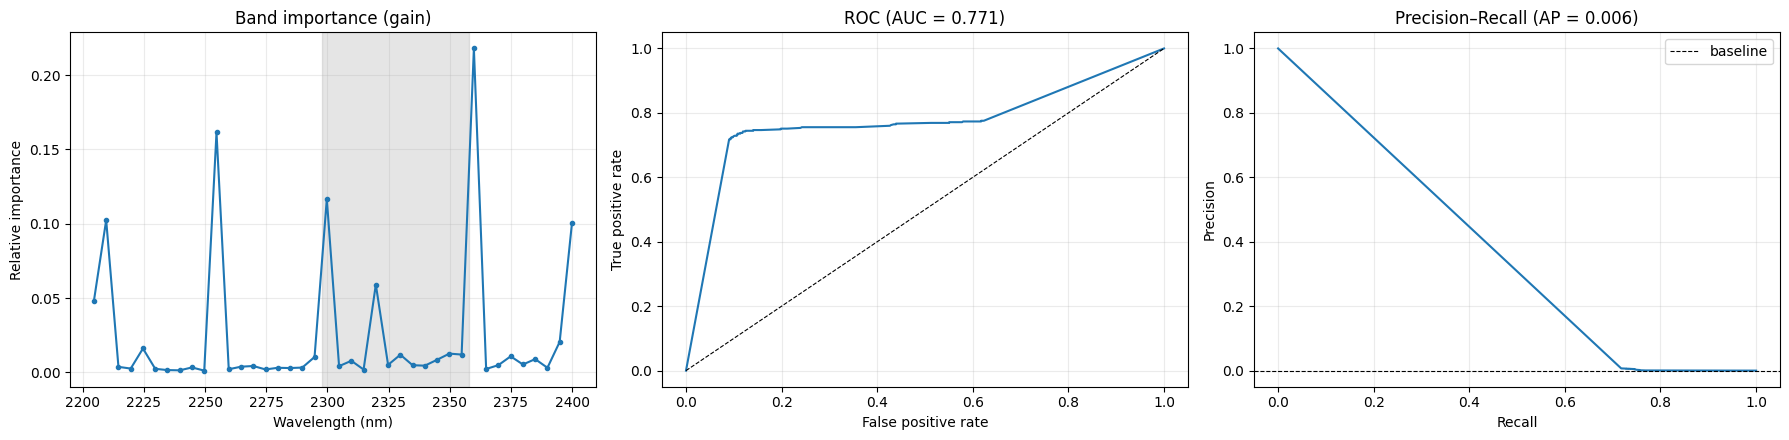

In [33]:
from sklearn.metrics import precision_recall_curve, average_precision_score

gain = model.booster_.feature_importance(importance_type="gain")
fpr, tpr, _ = roc_curve(y_test, prob_test)
prec, rec, _ = precision_recall_curve(y_test, prob_test)
ap = average_precision_score(y_test, prob_test)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

axes[0].plot(ch4_wavelengths, gain / gain.sum(), marker=".")
axes[0].axvspan(CH4_ABS_MIN, CH4_ABS_MAX, color="gray", alpha=0.2)
axes[0].set(title="Band importance (gain)", xlabel="Wavelength (nm)", ylabel="Relative importance")

axes[1].plot(fpr, tpr)
axes[1].plot([0, 1], [0, 1], "k--", lw=0.8)
axes[1].set(title=f"ROC (AUC = {roc_auc:.3f})", xlabel="False positive rate", ylabel="True positive rate")

axes[2].plot(rec, prec)
axes[2].axhline(y_test.mean(), color="k", ls="--", lw=0.8, label="baseline")
axes[2].set(title=f"Precision–Recall (AP = {ap:.3f})", xlabel="Recall", ylabel="Precision")
axes[2].legend()

for ax in axes:
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(FIG_DIR / "s18_importance_roc_pr.png", dpi=150)
plt.show()

## 19. Detection Threshold

### English

The ML model produces a probability of CH₄:

$$
P(\mathrm{CH}_4)
$$

A detection threshold converts this probability into a binary prediction.

For the initial model, a threshold of 0.5 is used:

$$
P(\mathrm{CH}_4)\geq0.5
\Rightarrow
\mathrm{CH}_4
$$

The threshold can be adjusted later when independent images become available.

This ML probability threshold is different from the matched-filter threshold used to create the pseudo-labels.

---

## 19. 検出しきい値

### 日本語

MLモデルはCH₄である確率を出力する。

$$
P(\mathrm{CH}_4)
$$

この確率にしきい値を適用して、二値の検出結果を作成する。

初期モデルでは0.5を使用する。

$$
P(\mathrm{CH}_4)\geq0.5
\Rightarrow
\mathrm{CH}_4
$$

独立した画像データが得られた後、このしきい値を調整することができる。

なお、このML確率しきい値は、pseudo-labelを作成するために使用したmatched-filterのしきい値とは異なる。


In [34]:
DETECTION_THRESHOLD = 0.5

pred_test = (
    prob_test >= DETECTION_THRESHOLD
).astype(np.uint8)

print(f"Detection threshold: {DETECTION_THRESHOLD:.2f}")
print(f"Predicted CH4: {pred_test.sum():,}")
print(f"Predicted background: {(pred_test == 0).sum():,}")

Detection threshold: 0.50
Predicted CH4: 59,646
Predicted background: 393,303


## 20. Save the CH₄ Detection Model

### English

The trained LightGBM classifier is saved together with the preprocessing parameters required to apply the same feature representation to future AVIRIS-NG images.

The saved information includes:

* trained LightGBM model;
* CH₄ spectral range;
* continuum-removal absorption range;
* wavelength grid;
* ML detection threshold.

The model can then be applied to future images after the same preprocessing pipeline.

---

## 20. CH₄検出モデルの保存

### 日本語

学習したLightGBM分類器を、将来のAVIRIS-NG画像に同じ特徴量処理を適用するために必要な前処理情報とともに保存する。

保存する情報は以下のとおりである。

* 学習済みLightGBMモデル
* CH₄スペクトル範囲
* continuum除去の吸収範囲
* 波長グリッド
* ML検出しきい値

これにより、同じ前処理を行った将来の画像に対してモデルを適用できる。


In [35]:
# ------------------------------------------------------------
# Save model
# ------------------------------------------------------------

model_path = MODEL_DIR / "ch4_lightgbm_detector.joblib"

model_info = {
    "model": model,
    "ch4_min_nm": float(CH4_MIN),
    "ch4_max_nm": float(CH4_MAX),
    "abs_min_nm": float(CH4_ABS_MIN),
    "abs_max_nm": float(CH4_ABS_MAX),
    "wavelengths": ch4_wavelengths.copy(),
    "detection_threshold": float(DETECTION_THRESHOLD),
    "feature_type": "continuum_removed_ratio",
    "label_threshold_ppm_m": float(threshold),
}

joblib.dump(model_info, model_path)

print("=== MODEL SAVED ===")
print(f"Path: {model_path}")
print(f"Size: {model_path.stat().st_size / 1024**2:.2f} MB")

=== MODEL SAVED ===
Path: models/ch4_lightgbm_detector.joblib
Size: 1.04 MB


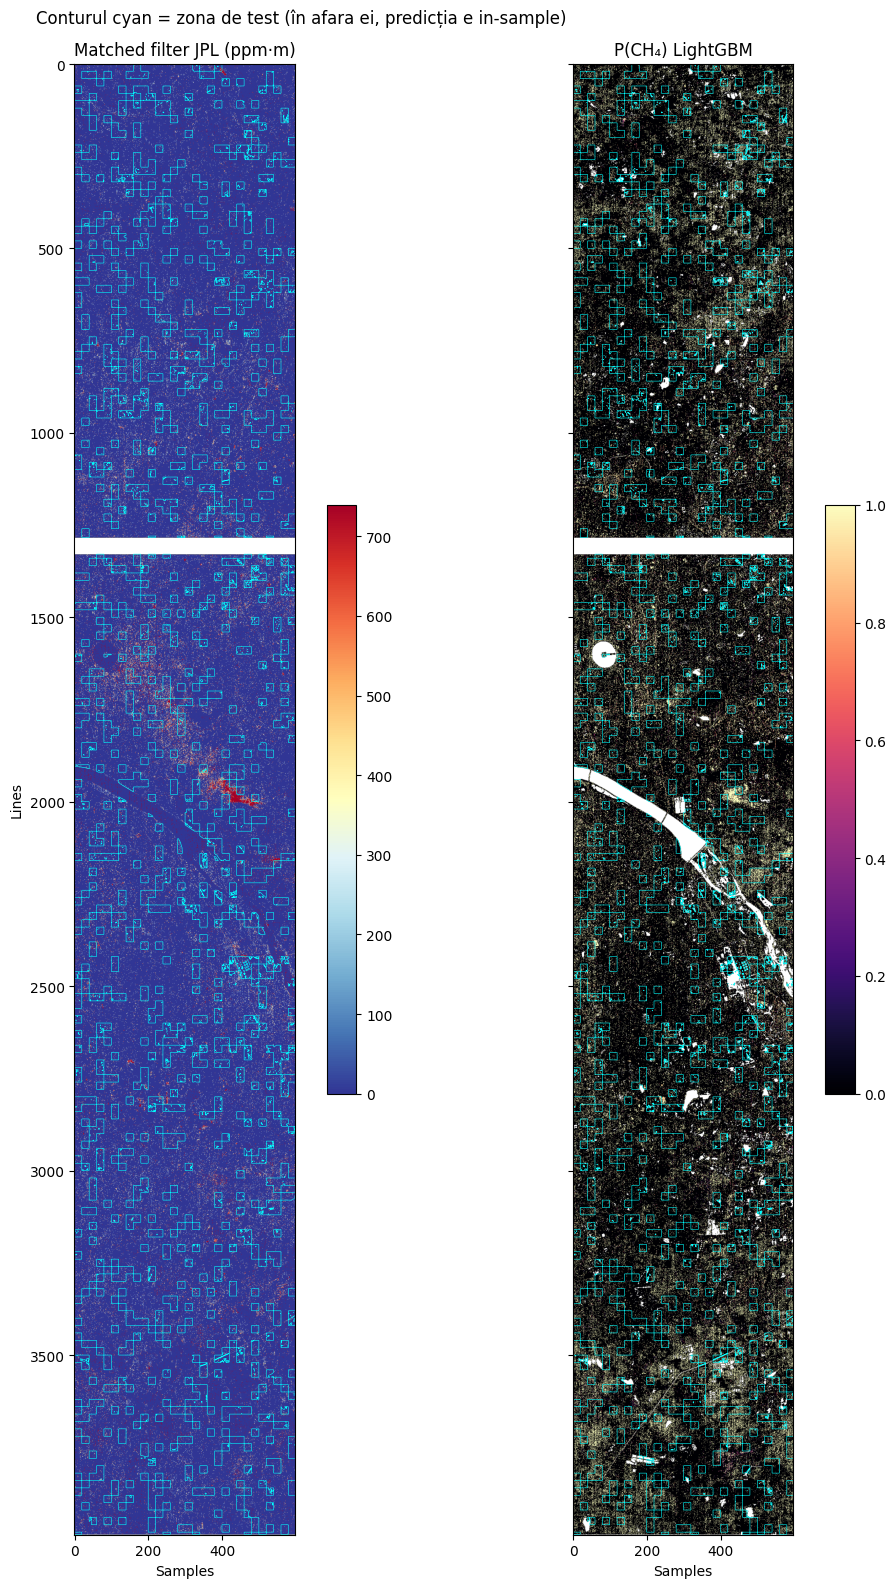

In [36]:
prob_all = model.predict_proba(X)[:, 1]

prob_map = np.full(ref.shape, np.nan, dtype=np.float32)
prob_map[rows, cols] = prob_all

test_map = np.zeros(ref.shape, dtype=bool)
test_map[rows[test_mask], cols[test_mask]] = True

fig, axes = plt.subplots(1, 2, figsize=(12, 16), sharey=True)

im0 = axes[0].imshow(ref, cmap="RdYlBu_r", vmin=0, vmax=np.nanpercentile(ref, 99))
axes[0].set_title("Matched filter JPL (ppm·m)")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(prob_map, cmap="magma", vmin=0, vmax=1)
axes[1].set_title("P(CH₄) LightGBM")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

for ax in axes:
    ax.contour(test_map, levels=[0.5], colors="cyan", linewidths=0.4)
    ax.set_xlabel("Samples")
axes[0].set_ylabel("Lines")

fig.suptitle("Conturul cyan = zona de test (în afara ei, predicția e in-sample)", y=0.99)
plt.tight_layout()
plt.savefig(FIG_DIR / "final_mf_vs_probability.png", dpi=150)
plt.show()

## 21. Conclusion / 結論

### English

**Summary**

This notebook demonstrates a complete, simple workflow for methane (CH₄) detection in AVIRIS-NG hyperspectral radiance data:

$$
\text{Radiance} \rightarrow \text{CH}_4\text{ window} \rightarrow \text{Continuum removal} \rightarrow \text{Pseudo-labels} \rightarrow \text{LightGBM} \rightarrow P(\text{CH}_4)
$$

The physical part of the pipeline (calibration checks, CH₄-sensitive window, shoulder-fit continuum removal, Beer–Lambert framing, and comparison with the modeled unit absorption spectrum) is documented and validated step by step. The trained LightGBM detector and its preprocessing parameters are saved for use on other images.

**Results**

On the spatially separated test set, the model reaches ROC-AUC = `[...]`, PR-AUC = `[...]`, precision = `[...]` and recall = `[...]` for the CH₄ class at a probability threshold of 0.5. The CH₄ class is about `[...]`% of the pixels, so accuracy is not informative and precision/recall/PR-AUC are the relevant metrics.

**Limitations**

1. **Pseudo-labels, not ground truth.** The labels come from the top 2% of positive JPL matched-filter values. The metrics measure how well the model reproduces this retrieval, not how well it detects real methane. The positive tail of the matched filter also contains noise, so some labels are wrong.
2. **Single scene.** Training and testing use one flight line. Good test scores do not show that the model generalizes to other scenes, surfaces, or atmospheric conditions.
3. **Spatial split.** Test blocks are spatially separated from training blocks, but plumes can be larger than a block, so some spatial leakage may remain.
4. **Uncalibrated threshold.** The probability threshold of 0.5 was not tuned. With `scale_pos_weight` the probabilities are not calibrated.
5. **Not a quantification.** The model outputs a detection probability, not a CH₄ concentration in ppm·m.

**Next steps**

- Train on several AVIRIS-NG scenes and test on scenes not seen in training.
- Use independent labels (for example known emission sources or manually verified plumes) in addition to the matched-filter threshold.
- Choose the detection threshold from the precision–recall curve on a validation set.
- Package preprocessing as one function used for both training and inference.

---

### 日本語

**まとめ**

本ノートブックでは、AVIRIS-NGのハイパースペクトル放射輝度データを用いたメタン（CH₄）検出の一連のワークフローを、簡潔に示した。

$$
\text{放射輝度} \rightarrow \text{CH}_4\text{窓} \rightarrow \text{Continuum除去} \rightarrow \text{Pseudo-label} \rightarrow \text{LightGBM} \rightarrow P(\text{CH}_4)
$$

物理的な処理（校正の確認、CH₄感度の高い波長窓、shoulderフィットによるcontinuum除去、Beer–Lambertの枠組み、モデル化された単位吸収スペクトルとの比較）は、各段階で確認した。学習済みLightGBM検出器と前処理パラメータは、他の画像で使用できるように保存した。

**結果**

空間的に分離したtestデータにおいて、確率しきい値0.5でのCH₄クラスの結果は、ROC-AUC = `[...]`、PR-AUC = `[...]`、Precision = `[...]`、Recall = `[...]` である。CH₄クラスは全画素の約 `[...]`% であるため、accuracyは有用な指標ではなく、precision・recall・PR-AUCが重要である。

**限界**

1. **Ground truthではなくpseudo-label。** ラベルは、JPL matched-filterの正の値の上位2%から作成した。評価指標は、実際のメタンの検出性能ではなく、このretrievalをどの程度再現できるかを示す。また、matched-filterの正の裾にはノイズも含まれるため、一部のラベルは誤りである。
2. **単一シーン。** 学習とテストには1つのフライトラインのみを使用した。testの結果が良くても、他のシーン、地表面、大気条件への汎化を示すものではない。
3. **空間分割。** testブロックはtrainブロックから空間的に分離されているが、プルームがブロックより大きい場合があり、空間的リークが残る可能性がある。
4. **未調整のしきい値。** 確率しきい値0.5は調整していない。`scale_pos_weight` を使用しているため、確率は較正されていない。
5. **定量ではない。** モデルの出力は検出確率であり、CH₄濃度（ppm·m）ではない。

**今後の課題**

- 複数のAVIRIS-NGシーンで学習し、学習に使用していないシーンで評価する。
- matched-filterのしきい値に加えて、独立したラベル（既知の排出源や目視で確認したプルームなど）を使用する。
- 検証データ上のPrecision–Recall曲線から検出しきい値を決定する。
- 前処理を1つの関数にまとめ、学習と推論の両方で使用する。